[LOAD] shape = (1000, 31)
[SPARE-DEMAND FILTER] count = 869 / 1000
[TIME SUMMARY] diag mean=2.98h | baseline wait mean=2417.42h | restore mean=8.75h
[CANDIDATE SCREENING]
  PMIN = 0.20
  long-lead threshold p95 = 7963.40h
  impact threshold p80 = 0.007743
  candidate spare-demand parts = 449 / 869
[BASE_MAINT_SPEND] 24,753,050 KRW
[NSGA] Gen 10/200 | best Ao=0.8891 | share(Ao>=0.94)=0.00 | mean managed=131.0
[NSGA] Gen 20/200 | best Ao=0.9079 | share(Ao>=0.94)=0.00 | mean managed=161.5
[NSGA] Gen 30/200 | best Ao=0.9187 | share(Ao>=0.94)=0.00 | mean managed=175.5
[NSGA] Gen 40/200 | best Ao=0.9231 | share(Ao>=0.94)=0.00 | mean managed=187.1
[NSGA] Gen 50/200 | best Ao=0.9315 | share(Ao>=0.94)=0.00 | mean managed=195.7
[NSGA] Gen 60/200 | best Ao=0.9330 | share(Ao>=0.94)=0.00 | mean managed=205.1
[NSGA] Gen 70/200 | best Ao=0.9377 | share(Ao>=0.94)=0.00 | mean managed=212.9
[NSGA] Gen 80/200 | best Ao=0.9386 | share(Ao>=0.94)=0.00 | mean managed=221.8
[NSGA] Gen 90/200 | best Ao=0.9417 

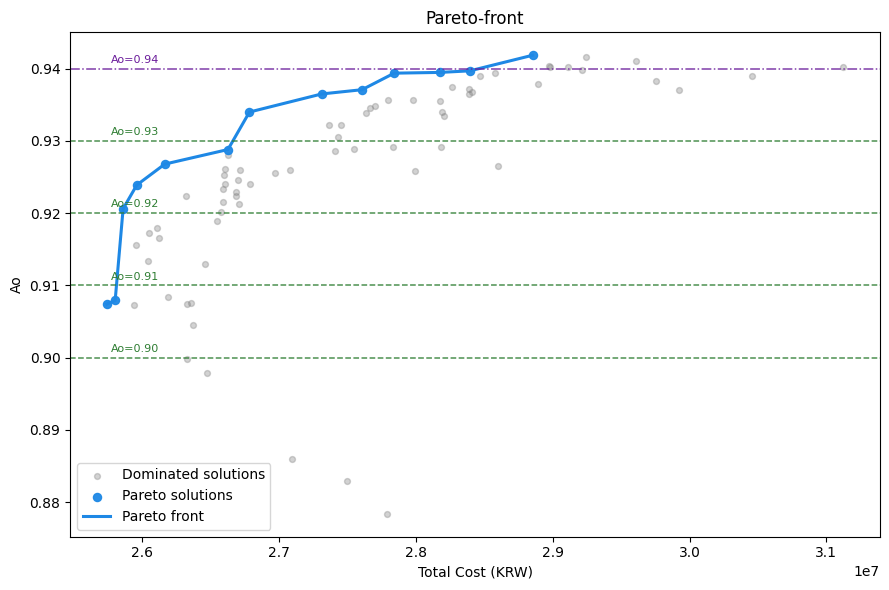


[TOP selected managed parts]
    Part_ID   Parent_ID  Level  Depth Maint_Echelon  annual_FR  lambda_eff_2y  p_need_2y  baseline_wait_h  T_diag_h  T_restore_h  ao_impact  is_long_lead  prebuy_flag  protection_flag  selected_manage  sO_best  sI_best  sD_best  total_stock_best  wait_per_failure_best  unit_proc_cost  critical_weight
RAD-L6-0216 RAD-L5-0214      6      6             O   2.559677       5.119354   0.994020          4994.25      2.98     6.215917   0.219301             0            0                0                1        0        0        0                 0               0.300049        228594.0             1.00
RAD-L6-0999 RAD-L5-0995      6      6             O   0.147725       0.295450   0.255803          3273.00      2.98     4.824516   0.013278             0            0                0                1        0        0        0                 0               0.300004        303245.0             0.15
RAD-L6-1000 RAD-L5-0995      6      6             O   0.134608  

In [12]:
# ============================================================
# COLAB ONE-CHUNK CODE
# NSGA-II baseline model
# + tuned baseline wait parameters
# + Pareto front visualization with dominated solutions
# + Ao lines from 0.90 to 0.94
# ------------------------------------------------------------
# 수정사항
#   1) BASELINE_WAIT_FRACTION_BY_ECHELON 조정
#      O: 0.25, I: 0.35, D: 0.50
#   2) MIN_WAIT_FLOOR_H_BY_ECHELON 조정
#      O: 1.0, I: 2.0, D: 4.0
# ------------------------------------------------------------
# 유지사항
#   - SoH/Env 가중치 미적용 baseline
#   - baseline support 반영
#   - real spare-demand parts 중심 최적화
#   - Parent_ID 기반 sibling 정규화(중복누적 완화)
#   - Maint_Echelon 기반 O/I/D 계층형 재고
#   - DT_total = DT_diag + DT_wait + DT_restore
#   - Ao = T_obs / (T_obs + DT_total)
#   - Pareto front + dominated solutions + Ao 0.90~0.94 lines
# ============================================================

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0) File load
# ============================================================
USE_COLAB_UPLOAD = False

if USE_COLAB_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    XLSX_PATH = list(uploaded.keys())[0]
else:
    XLSX_PATH = "radar_1000_parts_bom.xlsx"

df = pd.read_excel(XLSX_PATH, sheet_name=0)
print(f"[LOAD] shape = {df.shape}")


# ============================================================
# 1) Column helpers
# ============================================================
def find_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

col_part = find_col(df, ["Part_ID"])
col_parent = find_col(df, ["Parent_ID"])
col_level = find_col(df, ["Level"])
col_echelon = find_col(df, ["Maint_Echelon"])
col_fr = find_col(df, ["Failure_Rate"])
col_price = find_col(df, ["Unit_Price_KRW"])
col_transport_cost = find_col(df, ["Transport_Cost_KRW"])
col_lead = find_col(df, ["Total_Lead_Time_H"])
col_transport_time = find_col(df, ["Transport_Time_H"])
col_cm_cost = find_col(df, ["CM_Cost_KRW"])
col_cm_time = find_col(df, ["CM_Time_Hours"])
col_condemn = find_col(df, ["Condemnation_Rate_Pct"])
col_pm = find_col(df, ["PM_Cycle"])

required = [col_part, col_parent, col_level, col_echelon, col_fr]
if any(x is None for x in required):
    raise ValueError({
        "Part_ID": col_part,
        "Parent_ID": col_parent,
        "Level": col_level,
        "Maint_Echelon": col_echelon,
        "Failure_Rate": col_fr
    })

for c in [col_price, col_transport_cost, col_lead, col_transport_time, col_fr, col_cm_cost, col_cm_time, col_condemn]:
    if c is not None:
        df[c] = pd.to_numeric(df[c], errors="coerce")


# ============================================================
# 2) Settings
# ============================================================
YEARS = 2.0
T_OBS_HOURS = YEARS * 365.0 * 24.0
HOURS_PER_YEAR = 365.0 * 24.0

AO_TARGET = 0.94
AO_LINES = [0.90, 0.91, 0.92, 0.93, 0.94]

PMIN = 0.20
LONG_LEAD_PERCENTILE = 95
AO_IMPACT_PERCENTILE = 80
LONG_CORE_IMPACT_PERCENTILE = 70

POP = 80
GEN = 200
SEED = 42

AO_COST_PENALTY = 8.0e8
ITEM_COUNT_WEIGHT = 1.0
STOCK_UNIT_WEIGHT = 0.05
h_pre = 0.05

ABS_CAP_SMALL = 3
ABS_CAP_MED = 4
ABS_CAP_LARGE = 6

# ------------------------------------------------------------
# tuned baseline support parameters
# ------------------------------------------------------------
BASELINE_WAIT_FRACTION_BY_ECHELON = {
    "O": 0.75,
    "I": 0.9,
    "D": 1,
}
MIN_WAIT_FLOOR_H_BY_ECHELON = {
    "O": 1.0,
    "I": 6.0,
    "D": 24.0,
}

TOPK_PRINT = 15


# ============================================================
# 3) Helpers
# ============================================================
def minmax(x):
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    if hi - lo < 1e-12:
        return np.zeros_like(x, dtype=float)
    return (x - lo) / (hi - lo)

def parse_level_to_int(v):
    if pd.isna(v):
        return 0
    s = str(v)
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else 0

def map_echelon(v):
    if pd.isna(v):
        return "X"
    s = str(v).strip().lower()

    if any(k in s for k in ["organizational", "operational", "operator", "field", "unit", "line", "o-level", "o level"]):
        return "O"
    if any(k in s for k in ["현장", "운용", "부대", "일선"]):
        return "O"

    if any(k in s for k in ["intermediate", "support", "shop", "base", "i-level", "i level", "direct support"]):
        return "I"
    if any(k in s for k in ["중간", "야전정비", "지원", "정비대"]):
        return "I"

    if any(k in s for k in ["depot", "factory", "overhaul", "sustainment", "d-level", "d level"]):
        return "D"
    if any(k in s for k in ["창정비", "공창", "후방"]):
        return "D"

    if s in ["o", "org", "op"]:
        return "O"
    if s in ["i", "int"]:
        return "I"
    if s in ["d", "dep"]:
        return "D"

    return "X"

def pm_cycle_to_days(v):
    if pd.isna(v):
        return np.nan

    if isinstance(v, (int, float, np.integer, np.floating)):
        x = float(v)
        if x <= 0:
            return np.nan
        return x if x <= 400 else np.nan

    s = str(v).strip().lower()
    if s in ["", "nan", "none", "null"]:
        return np.nan

    if "분기" in s or "quarter" in s:
        return 365.0 / 4.0
    if "반기" in s or "semi" in s or "half" in s:
        return 365.0 / 2.0
    if "연" in s or "annual" in s or "year" in s:
        return 365.0

    m = re.search(r"(\d+(\.\d+)?)\s*(day|days|d|month|months|m|year|years|y)", s)
    if m:
        val = float(m.group(1))
        unit = m.group(3)
        if unit in ["day", "days", "d"]:
            return val
        if unit in ["month", "months", "m"]:
            return val * 30.4167
        if unit in ["year", "years", "y"]:
            return val * 365.0

    m2 = re.search(r"(\d+(\.\d+)?)", s)
    if m2:
        return float(m2.group(1))

    return np.nan

def poisson_tail_prob(mu, s):
    mu = float(max(mu, 0.0))
    s = int(max(s, 0))
    if mu < 1e-12:
        return 0.0

    term = math.exp(-mu)
    cdf = term
    for k in range(1, s + 1):
        term *= mu / k
        cdf += term
    tail = 1.0 - cdf
    return min(max(tail, 0.0), 1.0)

def long_dynamic_cap_from_lambda(lam_2y):
    base = int(np.ceil(lam_2y))
    if lam_2y < 1.0:
        buffer_i = 1
        abs_cap_i = ABS_CAP_SMALL
    elif lam_2y < 2.5:
        buffer_i = 1
        abs_cap_i = ABS_CAP_MED
    else:
        buffer_i = 2
        abs_cap_i = ABS_CAP_LARGE
    total_cap_i = min(base + buffer_i, abs_cap_i)
    return max(total_cap_i, 1)


# ============================================================
# 4) Raw arrays
# ============================================================
n_all = df.shape[0]

part_id_all = df[col_part].astype(str).to_numpy()
parent_id_all = df[col_parent].astype(str).to_numpy()
level_num_all = df[col_level].apply(parse_level_to_int).to_numpy(int)
echelon_cat_all = df[col_echelon].apply(map_echelon).to_numpy()

FR_all = df[col_fr].fillna(0).clip(lower=0).to_numpy(float)

unit_price_all = df[col_price].fillna(0).clip(lower=0).to_numpy(float) if col_price else np.zeros(n_all)
transport_cost_all = df[col_transport_cost].fillna(0).clip(lower=0).to_numpy(float) if col_transport_cost else np.zeros(n_all)
proc_cost_all = unit_price_all + transport_cost_all

lead_raw_all = df[col_lead].to_numpy(float) if col_lead else np.full(n_all, np.nan)
transport_time_all = df[col_transport_time].fillna(0).clip(lower=0).to_numpy(float) if col_transport_time else np.zeros(n_all)
lead_all = (
    pd.Series(lead_raw_all)
    .fillna(pd.Series(transport_time_all))
    .fillna(0)
    .clip(lower=0)
    .to_numpy(float)
)

cm_cost_all = df[col_cm_cost].fillna(0).clip(lower=0).to_numpy(float) if col_cm_cost else np.zeros(n_all)
cm_time_all = df[col_cm_time].fillna(0).clip(lower=0).to_numpy(float) if col_cm_time else np.zeros(n_all)

if col_condemn:
    condemn_all = df[col_condemn].fillna(0).clip(lower=0, upper=100).to_numpy(float) / 100.0
else:
    condemn_all = np.zeros(n_all, dtype=float)

if col_pm:
    pm_days_all = df[col_pm].apply(pm_cycle_to_days).to_numpy(float)
else:
    pm_days_all = np.full(n_all, np.nan)

pm_freq_all = np.where(np.isfinite(pm_days_all) & (pm_days_all > 0), 365.0 / pm_days_all, 0.0)
pm_norm_all = np.clip(pm_freq_all / 4.0, 0.0, 1.0)

gamma_max = 0.10
delta_max = 0.05
gamma_all = gamma_max * pm_norm_all
delta_all = delta_max * pm_norm_all


# ============================================================
# 5) Build BOM structure
# ============================================================
part_to_idx = {pid: i for i, pid in enumerate(part_id_all)}

children_map = {i: [] for i in range(n_all)}
for i in range(n_all):
    p = parent_id_all[i]
    if pd.notna(p):
        p = str(p)
        if p in part_to_idx:
            children_map[part_to_idx[p]].append(i)

is_leaf_all = np.array([len(children_map[i]) == 0 for i in range(n_all)], dtype=bool)

def get_ancestor_chain(idx):
    chain_rev = [idx]
    seen = {idx}
    cur_parent = parent_id_all[idx]
    hop = 0
    while pd.notna(cur_parent) and str(cur_parent) not in ["", "nan", "None", "null"]:
        cur_parent = str(cur_parent)
        if cur_parent not in part_to_idx:
            break
        pidx = part_to_idx[cur_parent]
        if pidx in seen:
            break
        chain_rev.append(pidx)
        seen.add(pidx)
        cur_parent = parent_id_all[pidx]
        hop += 1
        if hop > 30:
            break
    return list(reversed(chain_rev))

all_ancestor_chains = [get_ancestor_chain(i) for i in range(n_all)]
depth_all = np.array([len(ch) for ch in all_ancestor_chains], dtype=int)


# ============================================================
# 6) Real spare-demand part selection
# ============================================================
has_physical_attr = (
    (unit_price_all > 0) |
    (cm_time_all > 0) |
    (lead_all > 0)
)

spare_demand_mask = (
    (level_num_all >= 3) &
    is_leaf_all &
    (FR_all > 0) &
    has_physical_attr
)

if spare_demand_mask.sum() < 20:
    spare_demand_mask = (
        (level_num_all >= 3) &
        (FR_all > 0) &
        has_physical_attr
    )

spare_idx = np.where(spare_demand_mask)[0]
print(f"[SPARE-DEMAND FILTER] count = {len(spare_idx)} / {n_all}")

if len(spare_idx) == 0:
    raise ValueError("No real spare-demand parts found.")


# ============================================================
# 7) Common arrays
# ============================================================
annual_fr_sp = FR_all[spare_idx] * (1.0 - gamma_all[spare_idx])
lam_2y_sp = annual_fr_sp * YEARS

proc_cost_sp = proc_cost_all[spare_idx]
lead_sp = lead_all[spare_idx]
transport_sp = transport_time_all[spare_idx]
cm_cost_sp = cm_cost_all[spare_idx]
cm_time_sp = cm_time_all[spare_idx]
condemn_sp = condemn_all[spare_idx]
delta_sp = delta_all[spare_idx]
level_sp = level_num_all[spare_idx]
depth_sp = depth_all[spare_idx]
echelon_sp = echelon_cat_all[spare_idx]
part_id_sp = part_id_all[spare_idx]
parent_id_sp = parent_id_all[spare_idx]
chains_sp = [all_ancestor_chains[i] for i in spare_idx]

# sibling normalization
parent_group_map = {}
for local_idx, global_idx in enumerate(spare_idx):
    p = parent_id_all[global_idx]
    p = str(p) if pd.notna(p) else f"ROOT_{part_id_all[global_idx]}"
    parent_group_map.setdefault(p, []).append(local_idx)

lambda_eff_sp = annual_fr_sp.copy()
for p, members in parent_group_map.items():
    if len(members) <= 1:
        continue
    fr_sub = annual_fr_sp[members]
    total = fr_sub.sum()
    if total > 1e-12:
        shares = fr_sub / total
        lambda_eff_sp[members] = total * shares / len(members) * 1.2
    else:
        lambda_eff_sp[members] = annual_fr_sp[members]

def node_diag_contrib(level_value):
    if level_value <= 1:
        return 0.10
    if level_value == 2:
        return 0.18
    if level_value == 3:
        return 0.35
    if level_value == 4:
        return 0.55
    if level_value == 5:
        return 0.80
    return 1.00

T_diag_sp = np.zeros(len(spare_idx), dtype=float)
for k, chain in enumerate(chains_sp):
    t = 0.0
    for node_idx in chain:
        lv = level_num_all[node_idx]
        t += node_diag_contrib(lv)
    T_diag_sp[k] = t

T_reminst_sp = 0.35 * np.maximum(cm_time_sp, 1.0)
T_repair_sp = 0.65 * cm_time_sp * (1.0 - delta_sp)

for i, e in enumerate(echelon_sp):
    if e == "O":
        T_reminst_sp[i] *= 0.85
        T_repair_sp[i] *= 0.75
    elif e == "I":
        T_reminst_sp[i] *= 1.00
        T_repair_sp[i] *= 1.00
    elif e == "D":
        T_reminst_sp[i] *= 1.15
        T_repair_sp[i] *= 1.25

T_restore_intrinsic_sp = T_reminst_sp + (1.0 - condemn_sp) * T_repair_sp

T_issue_O_sp = np.full(len(spare_idx), 0.3, dtype=float)
T_issue_I_sp = np.maximum(0.8, np.minimum(4.0, 0.25 * np.maximum(transport_sp, 1.0)))
T_issue_D_sp = np.maximum(1.5, np.minimum(8.0, 0.45 * np.maximum(transport_sp, 1.0)))

baseline_wait_sp = np.zeros(len(spare_idx), dtype=float)
for i, e in enumerate(echelon_sp):
    frac = BASELINE_WAIT_FRACTION_BY_ECHELON.get(e, 0.35)
    floor = MIN_WAIT_FLOOR_H_BY_ECHELON.get(e, 2.0)
    baseline_wait_sp[i] = max(floor, frac * lead_sp[i])

print(
    f"[TIME SUMMARY] "
    f"diag mean={T_diag_sp.mean():.2f}h | "
    f"baseline wait mean={baseline_wait_sp.mean():.2f}h | "
    f"restore mean={T_restore_intrinsic_sp.mean():.2f}h"
)


# ============================================================
# 8) Candidate screening
# ============================================================
p_need_sp = 1.0 - np.exp(-lam_2y_sp)

thr_lead = float(np.nanpercentile(lead_sp, LONG_LEAD_PERCENTILE))
is_long_sp = (lead_sp >= thr_lead)

impact_sp = lambda_eff_sp * np.maximum(T_diag_sp + baseline_wait_sp + T_restore_intrinsic_sp, 1e-9) / HOURS_PER_YEAR
thr_impact = float(np.nanpercentile(impact_sp, AO_IMPACT_PERCENTILE))
is_high_impact_sp = (impact_sp >= thr_impact)

candidate_mask = (p_need_sp >= PMIN) | is_high_impact_sp | is_long_sp
candidate_idx_local = np.where(candidate_mask)[0]

print("[CANDIDATE SCREENING]")
print(f"  PMIN = {PMIN:.2f}")
print(f"  long-lead threshold p{LONG_LEAD_PERCENTILE} = {thr_lead:.2f}h")
print(f"  impact threshold p{AO_IMPACT_PERCENTILE} = {thr_impact:.6f}")
print(f"  candidate spare-demand parts = {len(candidate_idx_local)} / {len(spare_idx)}")

if len(candidate_idx_local) == 0:
    raise ValueError("No candidate spare-demand parts after screening.")

part_id_c = part_id_sp[candidate_idx_local]
parent_id_c = parent_id_sp[candidate_idx_local]
level_c = level_sp[candidate_idx_local]
depth_c = depth_sp[candidate_idx_local]
echelon_c = echelon_sp[candidate_idx_local]

annual_fr_c = annual_fr_sp[candidate_idx_local]
lambda_eff_c = lambda_eff_sp[candidate_idx_local]
lam_2y_c = lam_2y_sp[candidate_idx_local]
proc_cost_c = proc_cost_sp[candidate_idx_local]
lead_c = lead_sp[candidate_idx_local]
cm_cost_c = cm_cost_sp[candidate_idx_local]

T_diag_c = T_diag_sp[candidate_idx_local]
T_reminst_c = T_reminst_sp[candidate_idx_local]
T_repair_c = T_repair_sp[candidate_idx_local]
T_restore_intrinsic_c = T_restore_intrinsic_sp[candidate_idx_local]
T_issue_O_c = T_issue_O_sp[candidate_idx_local]
T_issue_I_c = T_issue_I_sp[candidate_idx_local]
T_issue_D_c = T_issue_D_sp[candidate_idx_local]
baseline_wait_c = baseline_wait_sp[candidate_idx_local]

p_need_c = p_need_sp[candidate_idx_local]
impact_c = impact_sp[candidate_idx_local]
is_long_c = is_long_sp[candidate_idx_local]

m_cand = len(candidate_idx_local)
long_idx_c = np.where(is_long_c)[0]

if len(long_idx_c) > 0:
    long_core_thr = float(np.nanpercentile(impact_c[long_idx_c], LONG_CORE_IMPACT_PERCENTILE))
else:
    long_core_thr = 0.0

prebuy_flag_c = np.zeros(m_cand, dtype=bool)
protection_flag_c = np.zeros(m_cand, dtype=bool)
for j in range(m_cand):
    if is_long_c[j] and ((p_need_c[j] >= PMIN) or (impact_c[j] >= thr_impact)):
        prebuy_flag_c[j] = True
    if is_long_c[j] and (impact_c[j] >= long_core_thr):
        protection_flag_c[j] = True

impact_norm_c = minmax(impact_c)
critical_weight_c = np.where(
    impact_norm_c >= 0.80, 1.00,
    np.where(impact_norm_c >= 0.50, 0.45, 0.15)
)

mu_pipe_nom_c = lambda_eff_c * (baseline_wait_c + T_restore_intrinsic_c) / HOURS_PER_YEAR

stock_cap_c = np.zeros(m_cand, dtype=int)
for i in range(m_cand):
    if is_long_c[i]:
        stock_cap_c[i] = long_dynamic_cap_from_lambda(lam_2y_c[i])
    else:
        stock_cap_c[i] = max(
            1,
            int(np.ceil(mu_pipe_nom_c[i] + 4.0 * np.sqrt(max(mu_pipe_nom_c[i], 1e-9)) + 2.0))
        )

prot_floor_c = np.where(protection_flag_c, 1, 0).astype(int)
BASE_MAINT_SPEND = float(np.sum(annual_fr_c * cm_cost_c * YEARS))

print(f"[BASE_MAINT_SPEND] {BASE_MAINT_SPEND:,.0f} KRW")


# ============================================================
# 9) Evaluate one solution
# ============================================================
def evaluate_one_solution(y_manage, sO, sI, sD):
    y_manage = np.asarray(y_manage, dtype=int)
    sO = np.asarray(sO, dtype=int)
    sI = np.asarray(sI, dtype=int)
    sD = np.asarray(sD, dtype=int)

    sO = y_manage * sO
    sI = y_manage * sI
    sD = y_manage * sD

    for i in range(m_cand):
        if y_manage[i] > 0 and prot_floor_c[i] > 0:
            if sO[i] + sI[i] + sD[i] < 1:
                if echelon_c[i] == "O":
                    sO[i] = 1
                elif echelon_c[i] == "I":
                    sI[i] = 1
                else:
                    sD[i] = 1

    total_stock = sO + sI + sD
    for i in range(m_cand):
        if total_stock[i] > stock_cap_c[i]:
            excess = total_stock[i] - stock_cap_c[i]
            reduc = min(sD[i], excess)
            sD[i] -= reduc
            excess -= reduc
            if excess > 0:
                reduc = min(sI[i], excess)
                sI[i] -= reduc
                excess -= reduc
            if excess > 0:
                reduc = min(sO[i], excess)
                sO[i] -= reduc
                excess -= reduc
        total_stock[i] = sO[i] + sI[i] + sD[i]

    p_short_O = np.zeros(m_cand, dtype=float)
    p_short_I = np.zeros(m_cand, dtype=float)
    p_short_D = np.zeros(m_cand, dtype=float)

    for i in range(m_cand):
        if y_manage[i] == 0:
            p_short_O[i] = 1.0
            p_short_I[i] = 1.0
            p_short_D[i] = 1.0
            continue

        muO = lambda_eff_c[i] * T_issue_O_c[i] / HOURS_PER_YEAR
        muI = lambda_eff_c[i] * T_issue_I_c[i] / HOURS_PER_YEAR
        muD = lambda_eff_c[i] * T_issue_D_c[i] / HOURS_PER_YEAR

        p_short_O[i] = poisson_tail_prob(muO, sO[i])
        p_short_I[i] = poisson_tail_prob(muI, sI[i])
        p_short_D[i] = poisson_tail_prob(muD, sD[i])

    improved_wait = (
        (1.0 - p_short_O) * T_issue_O_c
        + p_short_O * (1.0 - p_short_I) * T_issue_I_c
        + p_short_O * p_short_I * (1.0 - p_short_D) * T_issue_D_c
        + p_short_O * p_short_I * p_short_D * baseline_wait_c
    )

    T_wait_per_failure = np.where(
        y_manage > 0,
        np.minimum(baseline_wait_c, improved_wait),
        baseline_wait_c
    )

    DT_diag = np.sum(lambda_eff_c * T_diag_c * critical_weight_c)
    DT_restore = np.sum(lambda_eff_c * T_restore_intrinsic_c * critical_weight_c)
    DT_wait = np.sum(lambda_eff_c * T_wait_per_failure * critical_weight_c)
    DT_total = DT_diag + DT_wait + DT_restore

    Ao = float(T_OBS_HOURS / (T_OBS_HOURS + DT_total))

    stock_cost = float(np.sum(total_stock * proc_cost_c))
    hold_cost = float(h_pre * np.sum(total_stock * proc_cost_c))
    total_cost = stock_cost + hold_cost + BASE_MAINT_SPEND

    managed_items = int(np.sum((y_manage > 0) & (total_stock > 0)))
    total_stock_units = int(np.sum(total_stock))
    prebuy_selected = int(np.sum((y_manage > 0) & prebuy_flag_c))
    protection_selected = int(np.sum((total_stock > 0) & protection_flag_c))

    return {
        "Ao": Ao,
        "DT_diag_h": float(DT_diag),
        "DT_wait_h": float(DT_wait),
        "DT_restore_h": float(DT_restore),
        "DT_total_h": float(DT_total),
        "T_wait_per_failure": T_wait_per_failure,
        "total_cost": total_cost,
        "stock_cost": stock_cost,
        "hold_cost": hold_cost,
        "sO": sO,
        "sI": sI,
        "sD": sD,
        "total_stock": total_stock,
        "managed_items": managed_items,
        "total_stock_units": total_stock_units,
        "prebuy_selected": prebuy_selected,
        "protection_selected": protection_selected,
    }


# ============================================================
# 10) NSGA evaluation + utilities
# ============================================================
def eval_nsga(pop_mat):
    pop = pop_mat.shape[0]

    Y = np.clip(np.rint(pop_mat[:, :m_cand]), 0, 1).astype(int)
    SO = np.clip(np.rint(pop_mat[:, m_cand:m_cand+m_cand]), 0, None).astype(int)
    SI = np.clip(np.rint(pop_mat[:, m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
    SD = np.clip(np.rint(pop_mat[:, m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

    F = np.zeros((pop, 3), dtype=float)
    Ao = np.zeros(pop, dtype=float)

    for p in range(pop):
        sim = evaluate_one_solution(Y[p], SO[p], SI[p], SD[p])

        Ao[p] = sim["Ao"]
        ao_shortfall = max(0.0, AO_TARGET - sim["Ao"])

        F1 = sim["total_cost"] + AO_COST_PENALTY * (ao_shortfall ** 2)
        F2 = ao_shortfall
        F3 = ITEM_COUNT_WEIGHT * sim["managed_items"] + STOCK_UNIT_WEIGHT * sim["total_stock_units"]

        F[p, 0] = F1
        F[p, 1] = F2
        F[p, 2] = F3

    return F, Ao

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)

def fast_non_dominated_sort(F):
    n = F.shape[0]
    S = [[] for _ in range(n)]
    n_dom = np.zeros(n, dtype=int)
    fronts = [[]]

    for p in range(n):
        for q in range(n):
            if p == q:
                continue
            if dominates(F[p], F[q]):
                S[p].append(q)
            elif dominates(F[q], F[p]):
                n_dom[p] += 1
        if n_dom[p] == 0:
            fronts[0].append(p)

    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in S[p]:
                n_dom[q] -= 1
                if n_dom[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)

    fronts.pop()
    return fronts

def crowding_distance(F, front):
    mobj = F.shape[1]
    dist = np.zeros(len(front), dtype=float)
    if len(front) == 0:
        return dist

    idx = np.array(front, dtype=int)
    for j in range(mobj):
        vals = F[idx, j]
        order = np.argsort(vals)
        dist[order[0]] = np.inf
        dist[order[-1]] = np.inf

        vmin, vmax = vals[order[0]], vals[order[-1]]
        if vmax - vmin < 1e-12:
            continue

        for k in range(1, len(front) - 1):
            dist[order[k]] += (vals[order[k+1]] - vals[order[k-1]]) / (vmax - vmin)
    return dist

def rank_and_crowd(F):
    fronts = fast_non_dominated_sort(F)
    rank = np.empty(F.shape[0], dtype=int)
    crowd = np.zeros(F.shape[0], dtype=float)

    for rnk, front in enumerate(fronts):
        for i in front:
            rank[i] = rnk
        cd = crowding_distance(F, front)
        for t, i in enumerate(front):
            crowd[i] = cd[t]
    return rank, crowd, fronts

def tournament_select(rank, crowd, rng):
    i, j = rng.integers(0, len(rank), size=2)
    if rank[i] < rank[j]:
        return i
    if rank[j] < rank[i]:
        return j
    return i if crowd[i] > crowd[j] else j

def uniform_crossover(p1, p2, rng):
    mask = rng.random(p1.shape[0]) < 0.5
    c1, c2 = p1.copy(), p2.copy()
    c1[mask] = p2[mask]
    c2[mask] = p1[mask]
    return c1, c2


# ============================================================
# 11) Run NSGA-II
# ============================================================
def run_nsga(seed=42):
    rng = np.random.default_rng(seed)

    n_vars = m_cand + 3 * m_cand
    mut_p = float(np.clip(20.0 / max(n_vars, 1), 0.01, 0.06))

    pop = np.zeros((POP, n_vars), dtype=float)

    seed_prob = np.clip(
        0.12 + 0.55 * (
            0.45 * minmax(p_need_c) +
            0.35 * minmax(impact_c) +
            0.20 * is_long_c.astype(float)
        ),
        0.08, 0.85
    )

    for k in range(POP):
        for j in range(m_cand):
            pop[k, j] = 1 if rng.random() < seed_prob[j] else 0

        for j in range(m_cand):
            yj = int(pop[k, j])
            ub = stock_cap_c[j]
            if yj == 0:
                pop[k, m_cand + j] = 0
                pop[k, m_cand + m_cand + j] = 0
                pop[k, m_cand + 2*m_cand + j] = 0
            else:
                sO0, sI0, sD0 = 0, 0, 0
                if echelon_c[j] == "O":
                    sO0 = rng.integers(prot_floor_c[j], min(ub, 1) + 1)
                elif echelon_c[j] == "I":
                    sI0 = rng.integers(prot_floor_c[j], min(ub, 1) + 1)
                else:
                    sD0 = rng.integers(prot_floor_c[j], min(ub, 1) + 1)
                pop[k, m_cand + j] = sO0
                pop[k, m_cand + m_cand + j] = sI0
                pop[k, m_cand + 2*m_cand + j] = sD0

    def repair_solution(v):
        y = np.clip(np.rint(v[:m_cand]), 0, 1).astype(int)
        sO = np.clip(np.rint(v[m_cand:m_cand+m_cand]), 0, None).astype(int)
        sI = np.clip(np.rint(v[m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
        sD = np.clip(np.rint(v[m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

        for j in range(m_cand):
            if y[j] == 0:
                sO[j] = 0
                sI[j] = 0
                sD[j] = 0
            total = sO[j] + sI[j] + sD[j]
            cap = stock_cap_c[j]
            if total > cap:
                excess = total - cap
                reduc = min(sD[j], excess)
                sD[j] -= reduc
                excess -= reduc
                if excess > 0:
                    reduc = min(sI[j], excess)
                    sI[j] -= reduc
                    excess -= reduc
                if excess > 0:
                    reduc = min(sO[j], excess)
                    sO[j] -= reduc
                    excess -= reduc

        return np.concatenate([y, sO, sI, sD]).astype(float)

    def mutate(child):
        y = child.copy()

        msk_y = rng.random(m_cand) < mut_p
        for j in range(m_cand):
            if msk_y[j]:
                y[j] = 1.0 - round(y[j])

        for block in range(3):
            start = m_cand + block * m_cand
            msk_s = rng.random(m_cand) < mut_p
            for j in range(m_cand):
                idx = start + j
                if msk_s[j]:
                    ub = stock_cap_c[j]
                    y[idx] = rng.integers(0, ub + 1)

        y = repair_solution(y)
        return y

    for gen in range(GEN):
        F, Ao = eval_nsga(pop)
        rank, crowd, fronts = rank_and_crowd(F)

        off = []
        while len(off) < POP:
            p1 = tournament_select(rank, crowd, rng)
            p2 = tournament_select(rank, crowd, rng)
            c1, c2 = uniform_crossover(pop[p1], pop[p2], rng)
            c1 = mutate(c1)
            c2 = mutate(c2)
            off.append(c1)
            if len(off) < POP:
                off.append(c2)
        off = np.array(off, dtype=float)

        comb = np.vstack([pop, off])
        F_c, Ao_c = eval_nsga(comb)
        rank_c, crowd_c, fronts_c = rank_and_crowd(F_c)

        new_idx = []
        for front in fronts_c:
            if len(new_idx) + len(front) <= POP:
                new_idx.extend(front)
            else:
                front = np.array(front, dtype=int)
                order = np.argsort(-crowd_c[front])
                need = POP - len(new_idx)
                new_idx.extend(front[order[:need]].tolist())
                break

        pop = comb[np.array(new_idx, dtype=int)]

        if (gen + 1) % 10 == 0:
            Fp, Aop = eval_nsga(pop)
            managed_counts = []
            for row in pop:
                ytmp = np.clip(np.rint(row[:m_cand]), 0, 1).astype(int)
                managed_counts.append(int(np.sum(ytmp)))
            print(
                f"[NSGA] Gen {gen+1}/{GEN} | "
                f"best Ao={float(np.max(Aop)):.4f} | "
                f"share(Ao>=0.94)={float(np.mean(Aop >= AO_TARGET)):.2f} | "
                f"mean managed={float(np.mean(managed_counts)):.1f}"
            )

    F, Ao = eval_nsga(pop)
    cost = F[:, 0]

    F2d = np.column_stack([cost, -Ao])
    fronts2d = fast_non_dominated_sort(F2d)
    pareto_idx = np.array(fronts2d[0], dtype=int)
    dominated_idx = np.setdiff1d(np.arange(len(cost)), pareto_idx)

    order = np.argsort(cost[pareto_idx])
    p_idx = pareto_idx[order]

    best_idx = int(np.argmax(Ao))
    x = pop[best_idx]

    Y = np.clip(np.rint(x[:m_cand]), 0, 1).astype(int)
    SO = np.clip(np.rint(x[m_cand:m_cand+m_cand]), 0, None).astype(int)
    SI = np.clip(np.rint(x[m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
    SD = np.clip(np.rint(x[m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

    best_sim = evaluate_one_solution(Y, SO, SI, SD)

    return {
        "pop": pop,
        "F": F,
        "Ao": Ao,
        "cost": cost,
        "pareto_idx": pareto_idx,
        "dominated_idx": dominated_idx,
        "p_cost": cost[p_idx],
        "p_Ao": Ao[p_idx],
        "best_Ao": float(np.max(Ao)),
        "share_ge_target": float(np.mean(Ao >= AO_TARGET)),
        "best_sim": best_sim,
        "best_y": Y,
        "best_sO": SO,
        "best_sI": SI,
        "best_sD": SD,
    }


# ============================================================
# 12) Run
# ============================================================
res = run_nsga(seed=SEED)

print("\n==============================")
print("[FINAL SUMMARY]")
print(f"Best Ao = {res['best_Ao']:.4f}")
print(f"Share(Ao >= {AO_TARGET:.2f}) = {res['share_ge_target']:.2f}")
print(f"Candidate spare-demand parts = {m_cand}")
print("==============================")

b = res["best_sim"]
print("\n[BEST POLICY]")
print(f"Ao                  = {b['Ao']:.4f}")
print(f"DT_diag_h           = {b['DT_diag_h']:.2f}")
print(f"DT_wait_h           = {b['DT_wait_h']:.2f}")
print(f"DT_restore_h        = {b['DT_restore_h']:.2f}")
print(f"DT_total_h          = {b['DT_total_h']:.2f}")
print(f"stock_cost          = {b['stock_cost']:.0f}")
print(f"hold_cost           = {b['hold_cost']:.0f}")
print(f"total_cost          = {b['total_cost']:.0f}")
print(f"managed parts       = {b['managed_items']}")
print(f"total stock units   = {b['total_stock_units']}")
print(f"selected pre-buy    = {b['prebuy_selected']}")
print(f"selected protection = {b['protection_selected']}")


# ============================================================
# 13) Pareto front visualization
# ============================================================
plt.figure(figsize=(9, 6))

plt.scatter(
    res["cost"][res["dominated_idx"]],
    res["Ao"][res["dominated_idx"]],
    s=18,
    alpha=0.35,
    color="gray",
    label="Dominated solutions"
)

plt.scatter(
    res["p_cost"],
    res["p_Ao"],
    s=34,
    alpha=0.95,
    color="#1E88E5",
    label="Pareto solutions"
)
plt.plot(
    res["p_cost"],
    res["p_Ao"],
    linewidth=2.2,
    color="#1E88E5",
    label="Pareto front"
)


for ao_line in AO_LINES:
    color = "#2E7D32" if ao_line < AO_TARGET else "#6A1B9A"
    style = "--" if ao_line < AO_TARGET else "-."
    plt.axhline(
        ao_line,
        linestyle=style,
        linewidth=1.1,
        color=color,
        alpha=0.85
    )
    plt.text(
        x=np.nanmin(res["cost"]) * 1.001,
        y=ao_line + 0.0008,
        s=f"Ao={ao_line:.2f}",
        fontsize=8,
        color=color
    )

plt.xlabel("Total Cost (KRW)")
plt.ylabel("Ao")
plt.title("Pareto-front")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


# ============================================================
# 14) Diagnostics table
# ============================================================
diag_df = pd.DataFrame({
    "Part_ID": part_id_c,
    "Parent_ID": parent_id_c,
    "Level": level_c,
    "Depth": depth_c,
    "Maint_Echelon": echelon_c,
    "annual_FR": annual_fr_c,
    "lambda_eff_2y": lam_2y_c,
    "p_need_2y": p_need_c,
    "baseline_wait_h": baseline_wait_c,
    "T_diag_h": T_diag_c,
    "T_restore_h": T_restore_intrinsic_c,
    "ao_impact": impact_c,
    "is_long_lead": is_long_c.astype(int),
    "prebuy_flag": prebuy_flag_c.astype(int),
    "protection_flag": protection_flag_c.astype(int),
    "selected_manage": res["best_y"].astype(int),
    "sO_best": res["best_sim"]["sO"].astype(int),
    "sI_best": res["best_sim"]["sI"].astype(int),
    "sD_best": res["best_sim"]["sD"].astype(int),
    "total_stock_best": res["best_sim"]["total_stock"].astype(int),
    "wait_per_failure_best": res["best_sim"]["T_wait_per_failure"],
    "unit_proc_cost": proc_cost_c,
    "critical_weight": critical_weight_c
})

print("\n[TOP selected managed parts]")
print(
    diag_df.loc[diag_df["selected_manage"] == 1]
    .sort_values(["wait_per_failure_best", "ao_impact"], ascending=[False, False])
    .head(TOPK_PRINT)
    .to_string(index=False)
)

print("\n[TOP unmanaged but high baseline-wait parts]")
print(
    diag_df.loc[diag_df["selected_manage"] == 0]
    .sort_values(["baseline_wait_h", "ao_impact"], ascending=[False, False])
    .head(TOPK_PRINT)
    .to_string(index=False)
)

print("\n[TOP protection candidates]")
print(
    diag_df.loc[diag_df["protection_flag"] == 1]
    .sort_values(["ao_impact", "baseline_wait_h"], ascending=[False, False])
    .head(TOPK_PRINT)
    .to_string(index=False)
)

In [4]:
# ============================================================
# 15) Pick a Pareto solution by target Ao and export results
# ============================================================
TARGET_AO_PICK = 0.9411
EXPORT_PREFIX = "pareto_pick"
AUTO_DOWNLOAD = False

pareto_sorted_idx = res["pareto_sorted_idx"]
pick_local = int(np.argmin(np.abs(res["Ao"][pareto_sorted_idx] - TARGET_AO_PICK)))
pick_idx = int(pareto_sorted_idx[pick_local])

pick_x = res["pop"][pick_idx]

pick_y = np.clip(np.rint(pick_x[:m_cand]), 0, 1).astype(int)
pick_sO = np.clip(np.rint(pick_x[m_cand:m_cand+m_cand]), 0, None).astype(int)
pick_sI = np.clip(np.rint(pick_x[m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
pick_sD = np.clip(np.rint(pick_x[m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

pick_sim = evaluate_one_solution(pick_y, pick_sO, pick_sI, pick_sD)

print("\n[PICKED PARETO SOLUTION]")
print(f"Requested Ao target   = {TARGET_AO_PICK:.4f}")
print(f"Selected Pareto Ao    = {pick_sim['Ao']:.4f}")
print(f"DT_diag_h             = {pick_sim['DT_diag_h']:.2f}")
print(f"DT_wait_h             = {pick_sim['DT_wait_h']:.2f}")
print(f"DT_restore_h          = {pick_sim['DT_restore_h']:.2f}")
print(f"DT_total_h            = {pick_sim['DT_total_h']:.2f}")
print(f"total_cost            = {pick_sim['total_cost']:.0f}")
print(f"managed parts         = {pick_sim['managed_items']}")
print(f"total stock units     = {pick_sim['total_stock_units']}")
print(f"selected pre-buy      = {pick_sim['prebuy_selected']}")
print(f"selected protection   = {pick_sim['protection_selected']}")

# summary dataframe
summary_df = pd.DataFrame([{
    "requested_Ao": TARGET_AO_PICK,
    "selected_Ao": pick_sim["Ao"],
    "DT_diag_h": pick_sim["DT_diag_h"],
    "DT_wait_h": pick_sim["DT_wait_h"],
    "DT_restore_h": pick_sim["DT_restore_h"],
    "DT_total_h": pick_sim["DT_total_h"],
    "total_cost": pick_sim["total_cost"],
    "stock_cost": pick_sim["stock_cost"],
    "hold_cost": pick_sim["hold_cost"],
    "managed_parts": pick_sim["managed_items"],
    "total_stock_units": pick_sim["total_stock_units"],
    "selected_prebuy": pick_sim["prebuy_selected"],
    "selected_protection": pick_sim["protection_selected"]
}])

# spare list dataframe
pick_diag_df = pd.DataFrame({
    "Part_ID": part_id_c,
    "Parent_ID": parent_id_c,
    "Level": level_c,
    "Depth": depth_c,
    "Maint_Echelon": echelon_c,
    "annual_FR": annual_fr_c,
    "lambda_eff_2y": lam_2y_c,
    "baseline_wait_h": baseline_wait_c,
    "T_diag_h": T_diag_c,
    "T_restore_h": T_restore_intrinsic_c,
    "ao_impact": impact_c,
    "selected_manage": pick_y.astype(int),
    "sO": pick_sim["sO"].astype(int),
    "sI": pick_sim["sI"].astype(int),
    "sD": pick_sim["sD"].astype(int),
    "total_stock": pick_sim["total_stock"].astype(int),
    "wait_per_failure": pick_sim["T_wait_per_failure"],
    "prebuy_flag": prebuy_flag_c.astype(int),
    "protection_flag": protection_flag_c.astype(int)
})

spare_list_df = pick_diag_df.loc[
    (pick_diag_df["selected_manage"] == 1) | (pick_diag_df["total_stock"] > 0)
].sort_values(
    ["total_stock", "ao_impact", "wait_per_failure"],
    ascending=[False, False, False]
)

summary_path_csv = f"{EXPORT_PREFIX}_summary.csv"
summary_path_xlsx = f"{EXPORT_PREFIX}_summary.xlsx"
spares_path_csv = f"{EXPORT_PREFIX}_spare_list.csv"
spares_path_xlsx = f"{EXPORT_PREFIX}_spare_list.xlsx"

summary_df.to_csv(summary_path_csv, index=False, encoding="utf-8-sig")
summary_df.to_excel(summary_path_xlsx, index=False)

spare_list_df.to_csv(spares_path_csv, index=False, encoding="utf-8-sig")
spare_list_df.to_excel(spares_path_xlsx, index=False)

print("\n[EXPORT FILES]")
print(summary_path_csv)
print(summary_path_xlsx)
print(spares_path_csv)
print(spares_path_xlsx)

if AUTO_DOWNLOAD:
    try:
        from google.colab import files
        files.download(summary_path_xlsx)
        files.download(spares_path_xlsx)
    except:
        pass

KeyError: 'pareto_sorted_idx'

[LOAD] shape = (1000, 31)
[SPARE-DEMAND FILTER] count = 869 / 1000
[TIME SUMMARY] diag mean=2.98h | baseline wait mean=2417.42h | restore mean=8.75h
[CANDIDATE SCREENING]
  PMIN = 0.20
  long-lead threshold p95 = 7963.40h
  impact threshold p80 = 0.007743
  candidate spare-demand parts = 449 / 869
[BASE_MAINT_SPEND] 24,753,050 KRW

[TARGET SWEEP] RUN START | target_ao = 0.10
[NSGA | target=0.10] Gen 10/200 | best Ao=0.8611 | share(Ao>=0.10)=1.00 | mean managed=90.2
[NSGA | target=0.10] Gen 20/200 | best Ao=0.8602 | share(Ao>=0.10)=1.00 | mean managed=90.5
[NSGA | target=0.10] Gen 30/200 | best Ao=0.8593 | share(Ao>=0.10)=1.00 | mean managed=88.0
[NSGA | target=0.10] Gen 40/200 | best Ao=0.8593 | share(Ao>=0.10)=1.00 | mean managed=88.5
[NSGA | target=0.10] Gen 50/200 | best Ao=0.8593 | share(Ao>=0.10)=1.00 | mean managed=88.3
[NSGA | target=0.10] Gen 60/200 | best Ao=0.8593 | share(Ao>=0.10)=1.00 | mean managed=88.9
[NSGA | target=0.10] Gen 70/200 | best Ao=0.8593 | share(Ao>=0.10)=1.0

/tmp/ipykernel_396/709686844.py:1229: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: float(np.mean(g["Ao"] >= g.name)))


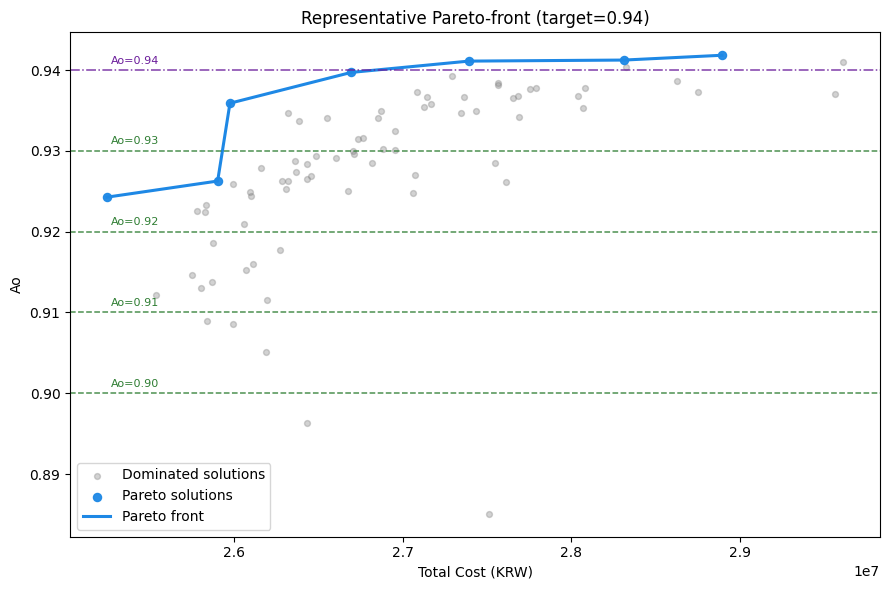

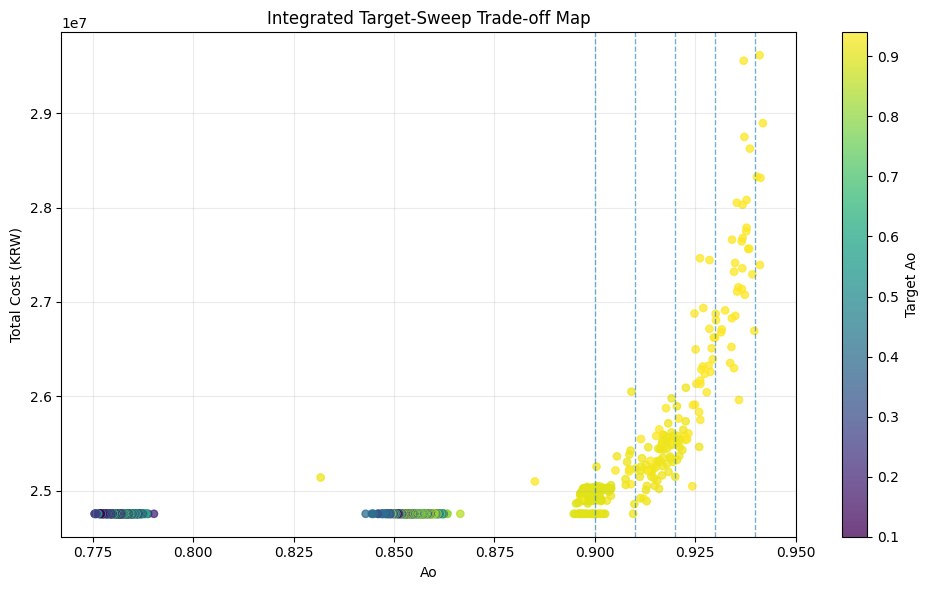

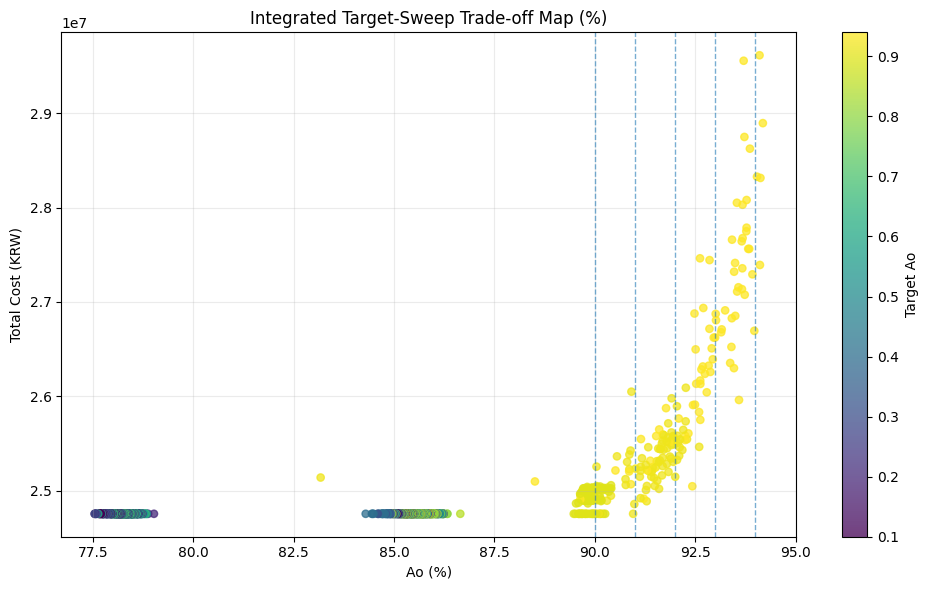

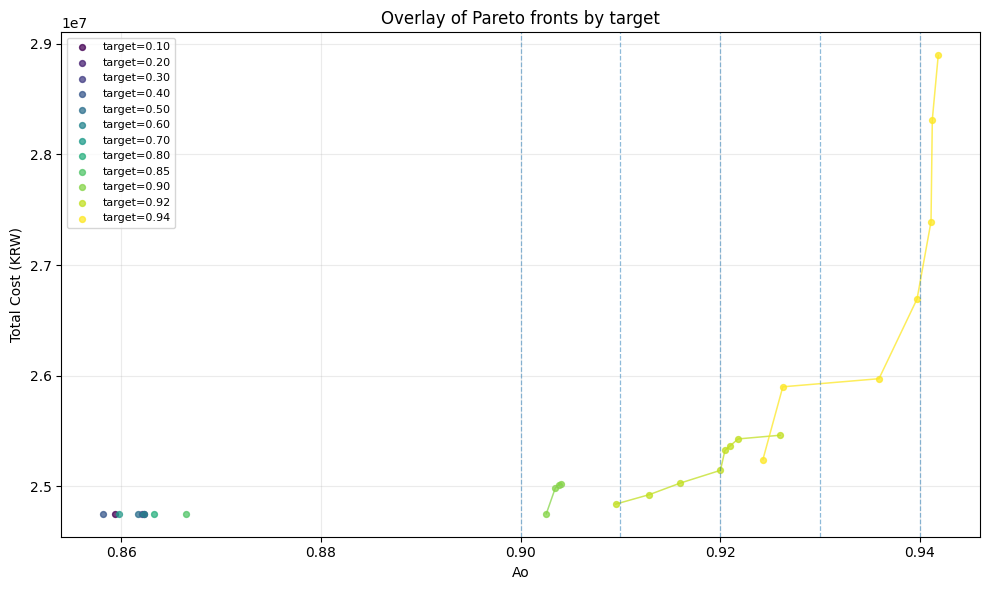


[TOP selected managed parts | representative target]
    Part_ID   Parent_ID  Level  Depth Maint_Echelon  annual_FR  lambda_eff_2y  p_need_2y  baseline_wait_h  T_diag_h  T_restore_h  ao_impact  is_long_lead  prebuy_flag  protection_flag  selected_manage  sO_best  sI_best  sD_best  total_stock_best  wait_per_failure_best  unit_proc_cost  critical_weight
RAD-L6-0216 RAD-L5-0214      6      6             O   2.559677       5.119354   0.994020          4994.25      2.98     6.215917   0.219301             0            0                0                1        0        0        0                 0               0.300049        228594.0             1.00
RAD-L6-0996 RAD-L5-0995      6      6             O   0.166569       0.333138   0.283329          3955.50      2.98     2.324133   0.018075             0            0                0                1        0        0        0                 0               0.300005        238210.0             0.15
RAD-L6-0999 RAD-L5-0995      6      6   

In [3]:
# ============================================================
# COLAB ONE-CHUNK CODE
# NSGA-II baseline model
# + target sweep integration (without changing objective/constraint structure)
# + Pareto front visualization with dominated solutions
# + integrated trade-off map across multiple Ao targets
# ------------------------------------------------------------
# 핵심
#   - 목적함수/제약식 구조는 그대로 유지
#   - AO_TARGET 하나만 고정하지 않고 AO_TARGET_GRID를 순회
#   - 각 target에서 NSGA-II를 반복 수행
#   - 결과를 합쳐 cost-Ao 통합 시각화
#   - 대표 target(기본 0.94)에 대해서 상세 진단표 출력
# ============================================================

import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0) File load
# ============================================================
USE_COLAB_UPLOAD = False

if USE_COLAB_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    XLSX_PATH = list(uploaded.keys())[0]
else:
    XLSX_PATH = "radar_1000_parts_bom.xlsx"

df = pd.read_excel(XLSX_PATH, sheet_name=0)
print(f"[LOAD] shape = {df.shape}")


# ============================================================
# 1) Column helpers
# ============================================================
def find_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

col_part = find_col(df, ["Part_ID"])
col_parent = find_col(df, ["Parent_ID"])
col_level = find_col(df, ["Level"])
col_echelon = find_col(df, ["Maint_Echelon"])
col_fr = find_col(df, ["Failure_Rate"])
col_price = find_col(df, ["Unit_Price_KRW"])
col_transport_cost = find_col(df, ["Transport_Cost_KRW"])
col_lead = find_col(df, ["Total_Lead_Time_H"])
col_transport_time = find_col(df, ["Transport_Time_H"])
col_cm_cost = find_col(df, ["CM_Cost_KRW"])
col_cm_time = find_col(df, ["CM_Time_Hours"])
col_condemn = find_col(df, ["Condemnation_Rate_Pct"])
col_pm = find_col(df, ["PM_Cycle"])

required = [col_part, col_parent, col_level, col_echelon, col_fr]
if any(x is None for x in required):
    raise ValueError({
        "Part_ID": col_part,
        "Parent_ID": col_parent,
        "Level": col_level,
        "Maint_Echelon": col_echelon,
        "Failure_Rate": col_fr
    })

for c in [col_price, col_transport_cost, col_lead, col_transport_time, col_fr, col_cm_cost, col_cm_time, col_condemn]:
    if c is not None:
        df[c] = pd.to_numeric(df[c], errors="coerce")


# ============================================================
# 2) Settings
# ============================================================
YEARS = 2.0
T_OBS_HOURS = YEARS * 365.0 * 24.0
HOURS_PER_YEAR = 365.0 * 24.0

# ------------------------------------------------------------
# target sweep
# ------------------------------------------------------------
AO_TARGET_GRID = [
    0.10, 0.20, 0.30, 0.40, 0.50,
    0.60, 0.70, 0.80, 0.85, 0.90,
    0.92, 0.94
]
REPRESENTATIVE_TARGET = 0.94   # 상세 진단표/대표 Pareto plot 기준
AO_LINES = [0.90, 0.91, 0.92, 0.93, 0.94]

PMIN = 0.20
LONG_LEAD_PERCENTILE = 95
AO_IMPACT_PERCENTILE = 80
LONG_CORE_IMPACT_PERCENTILE = 70

POP = 80
GEN = 200
SEED = 42

AO_COST_PENALTY = 8.0e8
ITEM_COUNT_WEIGHT = 1.0
STOCK_UNIT_WEIGHT = 0.05
h_pre = 0.05

ABS_CAP_SMALL = 3
ABS_CAP_MED = 4
ABS_CAP_LARGE = 6

# ------------------------------------------------------------
# tuned baseline support parameters
# ------------------------------------------------------------
BASELINE_WAIT_FRACTION_BY_ECHELON = {
    "O": 0.75,
    "I": 0.90,
    "D": 1.00,
}
MIN_WAIT_FLOOR_H_BY_ECHELON = {
    "O": 1.0,
    "I": 6.0,
    "D": 24.0,
}

TOPK_PRINT = 15


# ============================================================
# 3) Helpers
# ============================================================
def minmax(x):
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    if hi - lo < 1e-12:
        return np.zeros_like(x, dtype=float)
    return (x - lo) / (hi - lo)

def parse_level_to_int(v):
    if pd.isna(v):
        return 0
    s = str(v)
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else 0

def map_echelon(v):
    if pd.isna(v):
        return "X"
    s = str(v).strip().lower()

    if any(k in s for k in ["organizational", "operational", "operator", "field", "unit", "line", "o-level", "o level"]):
        return "O"
    if any(k in s for k in ["현장", "운용", "부대", "일선"]):
        return "O"

    if any(k in s for k in ["intermediate", "support", "shop", "base", "i-level", "i level", "direct support"]):
        return "I"
    if any(k in s for k in ["중간", "야전정비", "지원", "정비대"]):
        return "I"

    if any(k in s for k in ["depot", "factory", "overhaul", "sustainment", "d-level", "d level"]):
        return "D"
    if any(k in s for k in ["창정비", "공창", "후방"]):
        return "D"

    if s in ["o", "org", "op"]:
        return "O"
    if s in ["i", "int"]:
        return "I"
    if s in ["d", "dep"]:
        return "D"

    return "X"

def pm_cycle_to_days(v):
    if pd.isna(v):
        return np.nan

    if isinstance(v, (int, float, np.integer, np.floating)):
        x = float(v)
        if x <= 0:
            return np.nan
        return x if x <= 400 else np.nan

    s = str(v).strip().lower()
    if s in ["", "nan", "none", "null"]:
        return np.nan

    if "분기" in s or "quarter" in s:
        return 365.0 / 4.0
    if "반기" in s or "semi" in s or "half" in s:
        return 365.0 / 2.0
    if "연" in s or "annual" in s or "year" in s:
        return 365.0

    m = re.search(r"(\d+(\.\d+)?)\s*(day|days|d|month|months|m|year|years|y)", s)
    if m:
        val = float(m.group(1))
        unit = m.group(3)
        if unit in ["day", "days", "d"]:
            return val
        if unit in ["month", "months", "m"]:
            return val * 30.4167
        if unit in ["year", "years", "y"]:
            return val * 365.0

    m2 = re.search(r"(\d+(\.\d+)?)", s)
    if m2:
        return float(m2.group(1))

    return np.nan

def poisson_tail_prob(mu, s):
    mu = float(max(mu, 0.0))
    s = int(max(s, 0))
    if mu < 1e-12:
        return 0.0

    term = math.exp(-mu)
    cdf = term
    for k in range(1, s + 1):
        term *= mu / k
        cdf += term
    tail = 1.0 - cdf
    return min(max(tail, 0.0), 1.0)

def long_dynamic_cap_from_lambda(lam_2y):
    base = int(np.ceil(lam_2y))
    if lam_2y < 1.0:
        buffer_i = 1
        abs_cap_i = ABS_CAP_SMALL
    elif lam_2y < 2.5:
        buffer_i = 1
        abs_cap_i = ABS_CAP_MED
    else:
        buffer_i = 2
        abs_cap_i = ABS_CAP_LARGE
    total_cap_i = min(base + buffer_i, abs_cap_i)
    return max(total_cap_i, 1)

def solution_signature(y_manage, sO, sI, sD):
    return (
        "Y:" + ",".join(map(str, y_manage.astype(int).tolist())) +
        "|O:" + ",".join(map(str, sO.astype(int).tolist())) +
        "|I:" + ",".join(map(str, sI.astype(int).tolist())) +
        "|D:" + ",".join(map(str, sD.astype(int).tolist()))
    )


# ============================================================
# 4) Raw arrays
# ============================================================
n_all = df.shape[0]

part_id_all = df[col_part].astype(str).to_numpy()
parent_id_all = df[col_parent].astype(str).to_numpy()
level_num_all = df[col_level].apply(parse_level_to_int).to_numpy(int)
echelon_cat_all = df[col_echelon].apply(map_echelon).to_numpy()

FR_all = df[col_fr].fillna(0).clip(lower=0).to_numpy(float)

unit_price_all = df[col_price].fillna(0).clip(lower=0).to_numpy(float) if col_price else np.zeros(n_all)
transport_cost_all = df[col_transport_cost].fillna(0).clip(lower=0).to_numpy(float) if col_transport_cost else np.zeros(n_all)
proc_cost_all = unit_price_all + transport_cost_all

lead_raw_all = df[col_lead].to_numpy(float) if col_lead else np.full(n_all, np.nan)
transport_time_all = df[col_transport_time].fillna(0).clip(lower=0).to_numpy(float) if col_transport_time else np.zeros(n_all)
lead_all = (
    pd.Series(lead_raw_all)
    .fillna(pd.Series(transport_time_all))
    .fillna(0)
    .clip(lower=0)
    .to_numpy(float)
)

cm_cost_all = df[col_cm_cost].fillna(0).clip(lower=0).to_numpy(float) if col_cm_cost else np.zeros(n_all)
cm_time_all = df[col_cm_time].fillna(0).clip(lower=0).to_numpy(float) if col_cm_time else np.zeros(n_all)

if col_condemn:
    condemn_all = df[col_condemn].fillna(0).clip(lower=0, upper=100).to_numpy(float) / 100.0
else:
    condemn_all = np.zeros(n_all, dtype=float)

if col_pm:
    pm_days_all = df[col_pm].apply(pm_cycle_to_days).to_numpy(float)
else:
    pm_days_all = np.full(n_all, np.nan)

pm_freq_all = np.where(np.isfinite(pm_days_all) & (pm_days_all > 0), 365.0 / pm_days_all, 0.0)
pm_norm_all = np.clip(pm_freq_all / 4.0, 0.0, 1.0)

gamma_max = 0.10
delta_max = 0.05
gamma_all = gamma_max * pm_norm_all
delta_all = delta_max * pm_norm_all


# ============================================================
# 5) Build BOM structure
# ============================================================
part_to_idx = {pid: i for i, pid in enumerate(part_id_all)}

children_map = {i: [] for i in range(n_all)}
for i in range(n_all):
    p = parent_id_all[i]
    if pd.notna(p):
        p = str(p)
        if p in part_to_idx:
            children_map[part_to_idx[p]].append(i)

is_leaf_all = np.array([len(children_map[i]) == 0 for i in range(n_all)], dtype=bool)

def get_ancestor_chain(idx):
    chain_rev = [idx]
    seen = {idx}
    cur_parent = parent_id_all[idx]
    hop = 0
    while pd.notna(cur_parent) and str(cur_parent) not in ["", "nan", "None", "null"]:
        cur_parent = str(cur_parent)
        if cur_parent not in part_to_idx:
            break
        pidx = part_to_idx[cur_parent]
        if pidx in seen:
            break
        chain_rev.append(pidx)
        seen.add(pidx)
        cur_parent = parent_id_all[pidx]
        hop += 1
        if hop > 30:
            break
    return list(reversed(chain_rev))

all_ancestor_chains = [get_ancestor_chain(i) for i in range(n_all)]
depth_all = np.array([len(ch) for ch in all_ancestor_chains], dtype=int)


# ============================================================
# 6) Real spare-demand part selection
# ============================================================
has_physical_attr = (
    (unit_price_all > 0) |
    (cm_time_all > 0) |
    (lead_all > 0)
)

spare_demand_mask = (
    (level_num_all >= 3) &
    is_leaf_all &
    (FR_all > 0) &
    has_physical_attr
)

if spare_demand_mask.sum() < 20:
    spare_demand_mask = (
        (level_num_all >= 3) &
        (FR_all > 0) &
        has_physical_attr
    )

spare_idx = np.where(spare_demand_mask)[0]
print(f"[SPARE-DEMAND FILTER] count = {len(spare_idx)} / {n_all}")

if len(spare_idx) == 0:
    raise ValueError("No real spare-demand parts found.")


# ============================================================
# 7) Common arrays
# ============================================================
annual_fr_sp = FR_all[spare_idx] * (1.0 - gamma_all[spare_idx])
lam_2y_sp = annual_fr_sp * YEARS

proc_cost_sp = proc_cost_all[spare_idx]
lead_sp = lead_all[spare_idx]
transport_sp = transport_time_all[spare_idx]
cm_cost_sp = cm_cost_all[spare_idx]
cm_time_sp = cm_time_all[spare_idx]
condemn_sp = condemn_all[spare_idx]
delta_sp = delta_all[spare_idx]
level_sp = level_num_all[spare_idx]
depth_sp = depth_all[spare_idx]
echelon_sp = echelon_cat_all[spare_idx]
part_id_sp = part_id_all[spare_idx]
parent_id_sp = parent_id_all[spare_idx]
chains_sp = [all_ancestor_chains[i] for i in spare_idx]

# sibling normalization
parent_group_map = {}
for local_idx, global_idx in enumerate(spare_idx):
    p = parent_id_all[global_idx]
    p = str(p) if pd.notna(p) else f"ROOT_{part_id_all[global_idx]}"
    parent_group_map.setdefault(p, []).append(local_idx)

lambda_eff_sp = annual_fr_sp.copy()
for p, members in parent_group_map.items():
    if len(members) <= 1:
        continue
    fr_sub = annual_fr_sp[members]
    total = fr_sub.sum()
    if total > 1e-12:
        shares = fr_sub / total
        lambda_eff_sp[members] = total * shares / len(members) * 1.2
    else:
        lambda_eff_sp[members] = annual_fr_sp[members]

def node_diag_contrib(level_value):
    if level_value <= 1:
        return 0.10
    if level_value == 2:
        return 0.18
    if level_value == 3:
        return 0.35
    if level_value == 4:
        return 0.55
    if level_value == 5:
        return 0.80
    return 1.00

T_diag_sp = np.zeros(len(spare_idx), dtype=float)
for k, chain in enumerate(chains_sp):
    t = 0.0
    for node_idx in chain:
        lv = level_num_all[node_idx]
        t += node_diag_contrib(lv)
    T_diag_sp[k] = t

T_reminst_sp = 0.35 * np.maximum(cm_time_sp, 1.0)
T_repair_sp = 0.65 * cm_time_sp * (1.0 - delta_sp)

for i, e in enumerate(echelon_sp):
    if e == "O":
        T_reminst_sp[i] *= 0.85
        T_repair_sp[i] *= 0.75
    elif e == "I":
        T_reminst_sp[i] *= 1.00
        T_repair_sp[i] *= 1.00
    elif e == "D":
        T_reminst_sp[i] *= 1.15
        T_repair_sp[i] *= 1.25

T_restore_intrinsic_sp = T_reminst_sp + (1.0 - condemn_sp) * T_repair_sp

T_issue_O_sp = np.full(len(spare_idx), 0.3, dtype=float)
T_issue_I_sp = np.maximum(0.8, np.minimum(4.0, 0.25 * np.maximum(transport_sp, 1.0)))
T_issue_D_sp = np.maximum(1.5, np.minimum(8.0, 0.45 * np.maximum(transport_sp, 1.0)))

baseline_wait_sp = np.zeros(len(spare_idx), dtype=float)
for i, e in enumerate(echelon_sp):
    frac = BASELINE_WAIT_FRACTION_BY_ECHELON.get(e, 0.35)
    floor = MIN_WAIT_FLOOR_H_BY_ECHELON.get(e, 2.0)
    baseline_wait_sp[i] = max(floor, frac * lead_sp[i])

print(
    f"[TIME SUMMARY] "
    f"diag mean={T_diag_sp.mean():.2f}h | "
    f"baseline wait mean={baseline_wait_sp.mean():.2f}h | "
    f"restore mean={T_restore_intrinsic_sp.mean():.2f}h"
)


# ============================================================
# 8) Candidate screening
# ============================================================
p_need_sp = 1.0 - np.exp(-lam_2y_sp)

thr_lead = float(np.nanpercentile(lead_sp, LONG_LEAD_PERCENTILE))
is_long_sp = (lead_sp >= thr_lead)

impact_sp = lambda_eff_sp * np.maximum(T_diag_sp + baseline_wait_sp + T_restore_intrinsic_sp, 1e-9) / HOURS_PER_YEAR
thr_impact = float(np.nanpercentile(impact_sp, AO_IMPACT_PERCENTILE))
is_high_impact_sp = (impact_sp >= thr_impact)

candidate_mask = (p_need_sp >= PMIN) | is_high_impact_sp | is_long_sp
candidate_idx_local = np.where(candidate_mask)[0]

print("[CANDIDATE SCREENING]")
print(f"  PMIN = {PMIN:.2f}")
print(f"  long-lead threshold p{LONG_LEAD_PERCENTILE} = {thr_lead:.2f}h")
print(f"  impact threshold p{AO_IMPACT_PERCENTILE} = {thr_impact:.6f}")
print(f"  candidate spare-demand parts = {len(candidate_idx_local)} / {len(spare_idx)}")

if len(candidate_idx_local) == 0:
    raise ValueError("No candidate spare-demand parts after screening.")

part_id_c = part_id_sp[candidate_idx_local]
parent_id_c = parent_id_sp[candidate_idx_local]
level_c = level_sp[candidate_idx_local]
depth_c = depth_sp[candidate_idx_local]
echelon_c = echelon_sp[candidate_idx_local]

annual_fr_c = annual_fr_sp[candidate_idx_local]
lambda_eff_c = lambda_eff_sp[candidate_idx_local]
lam_2y_c = lam_2y_sp[candidate_idx_local]
proc_cost_c = proc_cost_sp[candidate_idx_local]
lead_c = lead_sp[candidate_idx_local]
cm_cost_c = cm_cost_sp[candidate_idx_local]

T_diag_c = T_diag_sp[candidate_idx_local]
T_reminst_c = T_reminst_sp[candidate_idx_local]
T_repair_c = T_repair_sp[candidate_idx_local]
T_restore_intrinsic_c = T_restore_intrinsic_sp[candidate_idx_local]
T_issue_O_c = T_issue_O_sp[candidate_idx_local]
T_issue_I_c = T_issue_I_sp[candidate_idx_local]
T_issue_D_c = T_issue_D_sp[candidate_idx_local]
baseline_wait_c = baseline_wait_sp[candidate_idx_local]

p_need_c = p_need_sp[candidate_idx_local]
impact_c = impact_sp[candidate_idx_local]
is_long_c = is_long_sp[candidate_idx_local]

m_cand = len(candidate_idx_local)
long_idx_c = np.where(is_long_c)[0]

if len(long_idx_c) > 0:
    long_core_thr = float(np.nanpercentile(impact_c[long_idx_c], LONG_CORE_IMPACT_PERCENTILE))
else:
    long_core_thr = 0.0

prebuy_flag_c = np.zeros(m_cand, dtype=bool)
protection_flag_c = np.zeros(m_cand, dtype=bool)
for j in range(m_cand):
    if is_long_c[j] and ((p_need_c[j] >= PMIN) or (impact_c[j] >= thr_impact)):
        prebuy_flag_c[j] = True
    if is_long_c[j] and (impact_c[j] >= long_core_thr):
        protection_flag_c[j] = True

impact_norm_c = minmax(impact_c)
critical_weight_c = np.where(
    impact_norm_c >= 0.80, 1.00,
    np.where(impact_norm_c >= 0.50, 0.45, 0.15)
)

mu_pipe_nom_c = lambda_eff_c * (baseline_wait_c + T_restore_intrinsic_c) / HOURS_PER_YEAR

stock_cap_c = np.zeros(m_cand, dtype=int)
for i in range(m_cand):
    if is_long_c[i]:
        stock_cap_c[i] = long_dynamic_cap_from_lambda(lam_2y_c[i])
    else:
        stock_cap_c[i] = max(
            1,
            int(np.ceil(mu_pipe_nom_c[i] + 4.0 * np.sqrt(max(mu_pipe_nom_c[i], 1e-9)) + 2.0))
        )

prot_floor_c = np.where(protection_flag_c, 1, 0).astype(int)
BASE_MAINT_SPEND = float(np.sum(annual_fr_c * cm_cost_c * YEARS))

print(f"[BASE_MAINT_SPEND] {BASE_MAINT_SPEND:,.0f} KRW")


# ============================================================
# 9) Evaluate one solution
# ============================================================
def evaluate_one_solution(y_manage, sO, sI, sD):
    y_manage = np.asarray(y_manage, dtype=int)
    sO = np.asarray(sO, dtype=int)
    sI = np.asarray(sI, dtype=int)
    sD = np.asarray(sD, dtype=int)

    sO = y_manage * sO
    sI = y_manage * sI
    sD = y_manage * sD

    for i in range(m_cand):
        if y_manage[i] > 0 and prot_floor_c[i] > 0:
            if sO[i] + sI[i] + sD[i] < 1:
                if echelon_c[i] == "O":
                    sO[i] = 1
                elif echelon_c[i] == "I":
                    sI[i] = 1
                else:
                    sD[i] = 1

    total_stock = sO + sI + sD
    for i in range(m_cand):
        if total_stock[i] > stock_cap_c[i]:
            excess = total_stock[i] - stock_cap_c[i]
            reduc = min(sD[i], excess)
            sD[i] -= reduc
            excess -= reduc
            if excess > 0:
                reduc = min(sI[i], excess)
                sI[i] -= reduc
                excess -= reduc
            if excess > 0:
                reduc = min(sO[i], excess)
                sO[i] -= reduc
                excess -= reduc
        total_stock[i] = sO[i] + sI[i] + sD[i]

    p_short_O = np.zeros(m_cand, dtype=float)
    p_short_I = np.zeros(m_cand, dtype=float)
    p_short_D = np.zeros(m_cand, dtype=float)

    for i in range(m_cand):
        if y_manage[i] == 0:
            p_short_O[i] = 1.0
            p_short_I[i] = 1.0
            p_short_D[i] = 1.0
            continue

        muO = lambda_eff_c[i] * T_issue_O_c[i] / HOURS_PER_YEAR
        muI = lambda_eff_c[i] * T_issue_I_c[i] / HOURS_PER_YEAR
        muD = lambda_eff_c[i] * T_issue_D_c[i] / HOURS_PER_YEAR

        p_short_O[i] = poisson_tail_prob(muO, sO[i])
        p_short_I[i] = poisson_tail_prob(muI, sI[i])
        p_short_D[i] = poisson_tail_prob(muD, sD[i])

    improved_wait = (
        (1.0 - p_short_O) * T_issue_O_c
        + p_short_O * (1.0 - p_short_I) * T_issue_I_c
        + p_short_O * p_short_I * (1.0 - p_short_D) * T_issue_D_c
        + p_short_O * p_short_I * p_short_D * baseline_wait_c
    )

    T_wait_per_failure = np.where(
        y_manage > 0,
        np.minimum(baseline_wait_c, improved_wait),
        baseline_wait_c
    )

    DT_diag = np.sum(lambda_eff_c * T_diag_c * critical_weight_c)
    DT_restore = np.sum(lambda_eff_c * T_restore_intrinsic_c * critical_weight_c)
    DT_wait = np.sum(lambda_eff_c * T_wait_per_failure * critical_weight_c)
    DT_total = DT_diag + DT_wait + DT_restore

    Ao = float(T_OBS_HOURS / (T_OBS_HOURS + DT_total))

    stock_cost = float(np.sum(total_stock * proc_cost_c))
    hold_cost = float(h_pre * np.sum(total_stock * proc_cost_c))
    total_cost = stock_cost + hold_cost + BASE_MAINT_SPEND

    managed_items = int(np.sum((y_manage > 0) & (total_stock > 0)))
    total_stock_units = int(np.sum(total_stock))
    prebuy_selected = int(np.sum((y_manage > 0) & prebuy_flag_c))
    protection_selected = int(np.sum((total_stock > 0) & protection_flag_c))

    return {
        "Ao": Ao,
        "DT_diag_h": float(DT_diag),
        "DT_wait_h": float(DT_wait),
        "DT_restore_h": float(DT_restore),
        "DT_total_h": float(DT_total),
        "T_wait_per_failure": T_wait_per_failure,
        "total_cost": total_cost,
        "stock_cost": stock_cost,
        "hold_cost": hold_cost,
        "sO": sO,
        "sI": sI,
        "sD": sD,
        "total_stock": total_stock,
        "managed_items": managed_items,
        "total_stock_units": total_stock_units,
        "prebuy_selected": prebuy_selected,
        "protection_selected": protection_selected,
    }


# ============================================================
# 10) NSGA evaluation + utilities
# ============================================================
def eval_nsga(pop_mat, ao_target):
    pop = pop_mat.shape[0]

    Y = np.clip(np.rint(pop_mat[:, :m_cand]), 0, 1).astype(int)
    SO = np.clip(np.rint(pop_mat[:, m_cand:m_cand+m_cand]), 0, None).astype(int)
    SI = np.clip(np.rint(pop_mat[:, m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
    SD = np.clip(np.rint(pop_mat[:, m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

    F = np.zeros((pop, 3), dtype=float)
    Ao = np.zeros(pop, dtype=float)

    for p in range(pop):
        sim = evaluate_one_solution(Y[p], SO[p], SI[p], SD[p])

        Ao[p] = sim["Ao"]
        ao_shortfall = max(0.0, ao_target - sim["Ao"])

        F1 = sim["total_cost"] + AO_COST_PENALTY * (ao_shortfall ** 2)
        F2 = ao_shortfall
        F3 = ITEM_COUNT_WEIGHT * sim["managed_items"] + STOCK_UNIT_WEIGHT * sim["total_stock_units"]

        F[p, 0] = F1
        F[p, 1] = F2
        F[p, 2] = F3

    return F, Ao

def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)

def fast_non_dominated_sort(F):
    n = F.shape[0]
    S = [[] for _ in range(n)]
    n_dom = np.zeros(n, dtype=int)
    fronts = [[]]

    for p in range(n):
        for q in range(n):
            if p == q:
                continue
            if dominates(F[p], F[q]):
                S[p].append(q)
            elif dominates(F[q], F[p]):
                n_dom[p] += 1
        if n_dom[p] == 0:
            fronts[0].append(p)

    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in S[p]:
                n_dom[q] -= 1
                if n_dom[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)

    fronts.pop()
    return fronts

def crowding_distance(F, front):
    mobj = F.shape[1]
    dist = np.zeros(len(front), dtype=float)
    if len(front) == 0:
        return dist

    idx = np.array(front, dtype=int)
    for j in range(mobj):
        vals = F[idx, j]
        order = np.argsort(vals)
        dist[order[0]] = np.inf
        dist[order[-1]] = np.inf

        vmin, vmax = vals[order[0]], vals[order[-1]]
        if vmax - vmin < 1e-12:
            continue

        for k in range(1, len(front) - 1):
            dist[order[k]] += (vals[order[k+1]] - vals[order[k-1]]) / (vmax - vmin)
    return dist

def rank_and_crowd(F):
    fronts = fast_non_dominated_sort(F)
    rank = np.empty(F.shape[0], dtype=int)
    crowd = np.zeros(F.shape[0], dtype=float)

    for rnk, front in enumerate(fronts):
        for i in front:
            rank[i] = rnk
        cd = crowding_distance(F, front)
        for t, i in enumerate(front):
            crowd[i] = cd[t]
    return rank, crowd, fronts

def tournament_select(rank, crowd, rng):
    i, j = rng.integers(0, len(rank), size=2)
    if rank[i] < rank[j]:
        return i
    if rank[j] < rank[i]:
        return j
    return i if crowd[i] > crowd[j] else j

def uniform_crossover(p1, p2, rng):
    mask = rng.random(p1.shape[0]) < 0.5
    c1, c2 = p1.copy(), p2.copy()
    c1[mask] = p2[mask]
    c2[mask] = p1[mask]
    return c1, c2


# ============================================================
# 11) Run NSGA-II (single target)
# ============================================================
def run_nsga_single_target(ao_target, seed=42):
    rng = np.random.default_rng(seed)

    n_vars = m_cand + 3 * m_cand
    mut_p = float(np.clip(20.0 / max(n_vars, 1), 0.01, 0.06))

    pop = np.zeros((POP, n_vars), dtype=float)

    seed_prob = np.clip(
        0.12 + 0.55 * (
            0.45 * minmax(p_need_c) +
            0.35 * minmax(impact_c) +
            0.20 * is_long_c.astype(float)
        ),
        0.08, 0.85
    )

    for k in range(POP):
        for j in range(m_cand):
            pop[k, j] = 1 if rng.random() < seed_prob[j] else 0

        for j in range(m_cand):
            yj = int(pop[k, j])
            ub = stock_cap_c[j]
            if yj == 0:
                pop[k, m_cand + j] = 0
                pop[k, m_cand + m_cand + j] = 0
                pop[k, m_cand + 2*m_cand + j] = 0
            else:
                sO0, sI0, sD0 = 0, 0, 0
                if echelon_c[j] == "O":
                    sO0 = rng.integers(prot_floor_c[j], min(ub, 1) + 1)
                elif echelon_c[j] == "I":
                    sI0 = rng.integers(prot_floor_c[j], min(ub, 1) + 1)
                else:
                    sD0 = rng.integers(prot_floor_c[j], min(ub, 1) + 1)
                pop[k, m_cand + j] = sO0
                pop[k, m_cand + m_cand + j] = sI0
                pop[k, m_cand + 2*m_cand + j] = sD0

    def repair_solution(v):
        y = np.clip(np.rint(v[:m_cand]), 0, 1).astype(int)
        sO = np.clip(np.rint(v[m_cand:m_cand+m_cand]), 0, None).astype(int)
        sI = np.clip(np.rint(v[m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
        sD = np.clip(np.rint(v[m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

        for j in range(m_cand):
            if y[j] == 0:
                sO[j] = 0
                sI[j] = 0
                sD[j] = 0
            total = sO[j] + sI[j] + sD[j]
            cap = stock_cap_c[j]
            if total > cap:
                excess = total - cap
                reduc = min(sD[j], excess)
                sD[j] -= reduc
                excess -= reduc
                if excess > 0:
                    reduc = min(sI[j], excess)
                    sI[j] -= reduc
                    excess -= reduc
                if excess > 0:
                    reduc = min(sO[j], excess)
                    sO[j] -= reduc
                    excess -= reduc

        return np.concatenate([y, sO, sI, sD]).astype(float)

    def mutate(child):
        y = child.copy()

        msk_y = rng.random(m_cand) < mut_p
        for j in range(m_cand):
            if msk_y[j]:
                y[j] = 1.0 - round(y[j])

        for block in range(3):
            start = m_cand + block * m_cand
            msk_s = rng.random(m_cand) < mut_p
            for j in range(m_cand):
                idx = start + j
                if msk_s[j]:
                    ub = stock_cap_c[j]
                    y[idx] = rng.integers(0, ub + 1)

        y = repair_solution(y)
        return y

    for gen in range(GEN):
        F, Ao = eval_nsga(pop, ao_target)
        rank, crowd, fronts = rank_and_crowd(F)

        off = []
        while len(off) < POP:
            p1 = tournament_select(rank, crowd, rng)
            p2 = tournament_select(rank, crowd, rng)
            c1, c2 = uniform_crossover(pop[p1], pop[p2], rng)
            c1 = mutate(c1)
            c2 = mutate(c2)
            off.append(c1)
            if len(off) < POP:
                off.append(c2)
        off = np.array(off, dtype=float)

        comb = np.vstack([pop, off])
        F_c, Ao_c = eval_nsga(comb, ao_target)
        rank_c, crowd_c, fronts_c = rank_and_crowd(F_c)

        new_idx = []
        for front in fronts_c:
            if len(new_idx) + len(front) <= POP:
                new_idx.extend(front)
            else:
                front = np.array(front, dtype=int)
                order = np.argsort(-crowd_c[front])
                need = POP - len(new_idx)
                new_idx.extend(front[order[:need]].tolist())
                break

        pop = comb[np.array(new_idx, dtype=int)]

        if (gen + 1) % 10 == 0:
            Fp, Aop = eval_nsga(pop, ao_target)
            managed_counts = []
            for row in pop:
                ytmp = np.clip(np.rint(row[:m_cand]), 0, 1).astype(int)
                managed_counts.append(int(np.sum(ytmp)))
            print(
                f"[NSGA | target={ao_target:.2f}] Gen {gen+1}/{GEN} | "
                f"best Ao={float(np.max(Aop)):.4f} | "
                f"share(Ao>={ao_target:.2f})={float(np.mean(Aop >= ao_target)):.2f} | "
                f"mean managed={float(np.mean(managed_counts)):.1f}"
            )

    F, Ao = eval_nsga(pop, ao_target)
    cost = F[:, 0]

    F2d = np.column_stack([cost, -Ao])
    fronts2d = fast_non_dominated_sort(F2d)
    pareto_idx = np.array(fronts2d[0], dtype=int)
    dominated_idx = np.setdiff1d(np.arange(len(cost)), pareto_idx)

    order = np.argsort(cost[pareto_idx])
    p_idx = pareto_idx[order]

    best_idx = int(np.argmax(Ao))
    x = pop[best_idx]

    Y = np.clip(np.rint(x[:m_cand]), 0, 1).astype(int)
    SO = np.clip(np.rint(x[m_cand:m_cand+m_cand]), 0, None).astype(int)
    SI = np.clip(np.rint(x[m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
    SD = np.clip(np.rint(x[m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

    best_sim = evaluate_one_solution(Y, SO, SI, SD)

    return {
        "target_ao": ao_target,
        "pop": pop,
        "F": F,
        "Ao": Ao,
        "cost": cost,
        "pareto_idx": pareto_idx,
        "dominated_idx": dominated_idx,
        "p_cost": cost[p_idx],
        "p_Ao": Ao[p_idx],
        "best_Ao": float(np.max(Ao)),
        "share_ge_target": float(np.mean(Ao >= ao_target)),
        "best_sim": best_sim,
        "best_y": Y,
        "best_sO": SO,
        "best_sI": SI,
        "best_sD": SD,
    }


# ============================================================
# 12) Sweep targets
# ============================================================
def collect_run_dataframe(res_single):
    rows = []

    pop = res_single["pop"]
    target_ao = res_single["target_ao"]

    Y = np.clip(np.rint(pop[:, :m_cand]), 0, 1).astype(int)
    SO = np.clip(np.rint(pop[:, m_cand:m_cand+m_cand]), 0, None).astype(int)
    SI = np.clip(np.rint(pop[:, m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
    SD = np.clip(np.rint(pop[:, m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

    pareto_set = set(res_single["pareto_idx"].tolist())

    for i in range(pop.shape[0]):
        sim = evaluate_one_solution(Y[i], SO[i], SI[i], SD[i])
        rows.append({
            "target_ao": float(target_ao),
            "solution_id_within_target": int(i),
            "Ao": float(sim["Ao"]),
            "total_cost": float(sim["total_cost"]),
            "stock_cost": float(sim["stock_cost"]),
            "hold_cost": float(sim["hold_cost"]),
            "DT_diag_h": float(sim["DT_diag_h"]),
            "DT_wait_h": float(sim["DT_wait_h"]),
            "DT_restore_h": float(sim["DT_restore_h"]),
            "DT_total_h": float(sim["DT_total_h"]),
            "managed_items": int(sim["managed_items"]),
            "total_stock_units": int(sim["total_stock_units"]),
            "is_pareto_2d": int(i in pareto_set),
            "signature": solution_signature(Y[i], sim["sO"], sim["sI"], sim["sD"]),
        })
    return pd.DataFrame(rows)

def run_target_sweep(target_grid, base_seed=42):
    all_result_map = {}
    all_df = []

    for idx, target in enumerate(target_grid):
        print("\n" + "=" * 70)
        print(f"[TARGET SWEEP] RUN START | target_ao = {target:.2f}")
        print("=" * 70)

        # 타겟별 seed를 조금 다르게 주어 해 다양성 확보
        run_seed = int(base_seed + idx * 17)

        res_t = run_nsga_single_target(ao_target=target, seed=run_seed)
        all_result_map[round(target, 6)] = res_t

        df_t = collect_run_dataframe(res_t)
        all_df.append(df_t)

        print(f"[TARGET SUMMARY] target={target:.2f} | best Ao={res_t['best_Ao']:.4f} | share_ge_target={res_t['share_ge_target']:.2f}")

    if len(all_df) == 0:
        return all_result_map, pd.DataFrame()

    df_all = pd.concat(all_df, ignore_index=True)
    return all_result_map, df_all


# ============================================================
# 13) Deduplicate integrated solutions
# ============================================================
def deduplicate_integrated_df(df_all):
    if df_all.empty:
        return df_all.copy()

    # 같은 정책이 여러 target에서 반복 등장할 수 있으므로 signature 기준 중복 제거
    # cost/Ao가 높은 target에서 재발견되더라도 정책 자체가 같으면 하나만 유지
    df_unique = (
        df_all.sort_values(
            by=["Ao", "total_cost", "target_ao"],
            ascending=[False, True, True]
        )
        .drop_duplicates(subset=["signature"])
        .reset_index(drop=True)
    )
    return df_unique


# ============================================================
# 14) Visualizations
# ============================================================
def plot_representative_pareto(res_single):
    plt.figure(figsize=(9, 6))

    plt.scatter(
        res_single["cost"][res_single["dominated_idx"]],
        res_single["Ao"][res_single["dominated_idx"]],
        s=18,
        alpha=0.35,
        color="gray",
        label="Dominated solutions"
    )

    plt.scatter(
        res_single["p_cost"],
        res_single["p_Ao"],
        s=34,
        alpha=0.95,
        color="#1E88E5",
        label="Pareto solutions"
    )
    plt.plot(
        res_single["p_cost"],
        res_single["p_Ao"],
        linewidth=2.2,
        color="#1E88E5",
        label="Pareto front"
    )

    for ao_line in AO_LINES:
        color = "#2E7D32" if ao_line < res_single["target_ao"] else "#6A1B9A"
        style = "--" if ao_line < res_single["target_ao"] else "-."
        plt.axhline(
            ao_line,
            linestyle=style,
            linewidth=1.1,
            color=color,
            alpha=0.85
        )
        plt.text(
            x=np.nanmin(res_single["cost"]) * 1.001,
            y=ao_line + 0.0008,
            s=f"Ao={ao_line:.2f}",
            fontsize=8,
            color=color
        )

    plt.xlabel("Total Cost (KRW)")
    plt.ylabel("Ao")
    plt.title(f"Representative Pareto-front (target={res_single['target_ao']:.2f})")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def plot_integrated_tradeoff_map(df_unique):
    if df_unique.empty:
        print("No integrated solutions to plot.")
        return

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(
        df_unique["Ao"],
        df_unique["total_cost"],
        c=df_unique["target_ao"],
        s=28,
        alpha=0.75
    )

    for ao_line in AO_LINES:
        plt.axvline(
            ao_line,
            linestyle="--",
            linewidth=1.0,
            alpha=0.6
        )

    plt.xlabel("Ao")
    plt.ylabel("Total Cost (KRW)")
    plt.title("Integrated Target-Sweep Trade-off Map")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, label="Target Ao")
    plt.tight_layout()
    plt.show()

def plot_integrated_tradeoff_map_percent(df_unique):
    if df_unique.empty:
        print("No integrated solutions to plot.")
        return

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(
        df_unique["Ao"] * 100.0,
        df_unique["total_cost"],
        c=df_unique["target_ao"],
        s=28,
        alpha=0.75
    )

    for ao_line in AO_LINES:
        plt.axvline(
            ao_line * 100.0,
            linestyle="--",
            linewidth=1.0,
            alpha=0.6
        )

    plt.xlabel("Ao (%)")
    plt.ylabel("Total Cost (KRW)")
    plt.title("Integrated Target-Sweep Trade-off Map (%)")
    plt.grid(True, alpha=0.25)
    plt.colorbar(sc, label="Target Ao")
    plt.tight_layout()
    plt.show()

def plot_targetwise_pareto_overlay(result_map):
    plt.figure(figsize=(10, 6))

    cmap = plt.cm.viridis
    targets_sorted = sorted(result_map.keys())

    for idx, t in enumerate(targets_sorted):
        res_t = result_map[t]
        color = cmap(idx / max(len(targets_sorted) - 1, 1))

        plt.scatter(
            res_t["p_Ao"],
            res_t["p_cost"],
            s=18,
            alpha=0.75,
            color=color,
            label=f"target={t:.2f}"
        )
        plt.plot(
            res_t["p_Ao"],
            res_t["p_cost"],
            linewidth=1.1,
            alpha=0.75,
            color=color
        )

    for ao_line in AO_LINES:
        plt.axvline(
            ao_line,
            linestyle="--",
            linewidth=0.9,
            alpha=0.5
        )

    plt.xlabel("Ao")
    plt.ylabel("Total Cost (KRW)")
    plt.title("Overlay of Pareto fronts by target")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


# ============================================================
# 15) Run sweep
# ============================================================
result_map, df_all_runs = run_target_sweep(AO_TARGET_GRID, base_seed=SEED)

df_integrated = deduplicate_integrated_df(df_all_runs)

print("\n" + "=" * 70)
print("[INTEGRATED SUMMARY]")
print(f"All collected solutions        = {len(df_all_runs)}")
print(f"Unique integrated solutions    = {len(df_integrated)}")
print("=" * 70)

summary_by_target_basic = (
    df_all_runs.groupby("target_ao")
    .agg(
        n_solutions=("Ao", "count"),
        ao_min=("Ao", "min"),
        ao_max=("Ao", "max"),
        cost_min=("total_cost", "min"),
        cost_max=("total_cost", "max"),
        wait_min=("DT_wait_h", "min"),
        wait_max=("DT_wait_h", "max"),
        managed_min=("managed_items", "min"),
        managed_max=("managed_items", "max"),
    )
    .reset_index()
)

share_df = (
    df_all_runs.groupby("target_ao")
    .apply(lambda g: float(np.mean(g["Ao"] >= g.name)))
    .reset_index(name="share_ge_target")
)

summary_by_target = (
    summary_by_target_basic
    .merge(share_df, on="target_ao", how="left")
    .sort_values("target_ao")
    .reset_index(drop=True)
)

print("\n[TARGET-WISE SUMMARY]")
print(summary_by_target.to_string(index=False))

rep_key = round(REPRESENTATIVE_TARGET, 6)
if rep_key not in result_map:
    raise ValueError(f"Representative target {REPRESENTATIVE_TARGET:.2f} is not in AO_TARGET_GRID.")

res = result_map[rep_key]


# ============================================================
# 16) Final representative summary
# ============================================================
print("\n==============================")
print("[FINAL SUMMARY | REPRESENTATIVE TARGET]")
print(f"Representative Target = {res['target_ao']:.2f}")
print(f"Best Ao = {res['best_Ao']:.4f}")
print(f"Share(Ao >= {res['target_ao']:.2f}) = {res['share_ge_target']:.2f}")
print(f"Candidate spare-demand parts = {m_cand}")
print("==============================")

b = res["best_sim"]
print("\n[BEST POLICY | REPRESENTATIVE TARGET]")
print(f"Ao                  = {b['Ao']:.4f}")
print(f"DT_diag_h           = {b['DT_diag_h']:.2f}")
print(f"DT_wait_h           = {b['DT_wait_h']:.2f}")
print(f"DT_restore_h        = {b['DT_restore_h']:.2f}")
print(f"DT_total_h          = {b['DT_total_h']:.2f}")
print(f"stock_cost          = {b['stock_cost']:.0f}")
print(f"hold_cost           = {b['hold_cost']:.0f}")
print(f"total_cost          = {b['total_cost']:.0f}")
print(f"managed parts       = {b['managed_items']}")
print(f"total stock units   = {b['total_stock_units']}")
print(f"selected pre-buy    = {b['prebuy_selected']}")
print(f"selected protection = {b['protection_selected']}")


# ============================================================
# 17) Plots
# ============================================================
plot_representative_pareto(res)
plot_integrated_tradeoff_map(df_integrated)
plot_integrated_tradeoff_map_percent(df_integrated)
plot_targetwise_pareto_overlay(result_map)


# ============================================================
# 18) Diagnostics table for representative target
# ============================================================
diag_df = pd.DataFrame({
    "Part_ID": part_id_c,
    "Parent_ID": parent_id_c,
    "Level": level_c,
    "Depth": depth_c,
    "Maint_Echelon": echelon_c,
    "annual_FR": annual_fr_c,
    "lambda_eff_2y": lam_2y_c,
    "p_need_2y": p_need_c,
    "baseline_wait_h": baseline_wait_c,
    "T_diag_h": T_diag_c,
    "T_restore_h": T_restore_intrinsic_c,
    "ao_impact": impact_c,
    "is_long_lead": is_long_c.astype(int),
    "prebuy_flag": prebuy_flag_c.astype(int),
    "protection_flag": protection_flag_c.astype(int),
    "selected_manage": res["best_y"].astype(int),
    "sO_best": res["best_sim"]["sO"].astype(int),
    "sI_best": res["best_sim"]["sI"].astype(int),
    "sD_best": res["best_sim"]["sD"].astype(int),
    "total_stock_best": res["best_sim"]["total_stock"].astype(int),
    "wait_per_failure_best": res["best_sim"]["T_wait_per_failure"],
    "unit_proc_cost": proc_cost_c,
    "critical_weight": critical_weight_c
})

print("\n[TOP selected managed parts | representative target]")
print(
    diag_df.loc[diag_df["selected_manage"] == 1]
    .sort_values(["wait_per_failure_best", "ao_impact"], ascending=[False, False])
    .head(TOPK_PRINT)
    .to_string(index=False)
)

print("\n[TOP unmanaged but high baseline-wait parts | representative target]")
print(
    diag_df.loc[diag_df["selected_manage"] == 0]
    .sort_values(["baseline_wait_h", "ao_impact"], ascending=[False, False])
    .head(TOPK_PRINT)
    .to_string(index=False)
)

print("\n[TOP protection candidates | representative target]")
print(
    diag_df.loc[diag_df["protection_flag"] == 1]
    .sort_values(["ao_impact", "baseline_wait_h"], ascending=[False, False])
    .head(TOPK_PRINT)
    .to_string(index=False)
)

In [1]:
# ============================================================
# EXTRA CODE
# Pick one Pareto solution -> part list + detailed interpretation
# -> save to Excel and download
# ------------------------------------------------------------
# 전제:
#   - 앞에서 올린 sweep 코드가 이미 실행되어 있어야 함
#   - 즉, 아래 변수들이 메모리에 있어야 함:
#       result_map, evaluate_one_solution, part_id_c, parent_id_c,
#       level_c, depth_c, echelon_c, annual_fr_c, lam_2y_c, p_need_c,
#       baseline_wait_c, T_diag_c, T_restore_intrinsic_c, impact_c,
#       is_long_c, prebuy_flag_c, protection_flag_c, proc_cost_c,
#       critical_weight_c, m_cand
# ============================================================

import numpy as np
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 1) USER SELECTION
# ------------------------------------------------------------
SELECT_TARGET_AO = 0.93

# 선택 방식
#   "closest_ao"  : Pareto 해 중 Ao가 SELECT_VALUE에 가장 가까운 해
#   "closest_cost": Pareto 해 중 total_cost가 SELECT_VALUE에 가장 가까운 해
#   "pareto_rank" : Pareto 해를 cost 오름차순 정렬했을 때 n번째 해 (0부터 시작)
SELECT_MODE = "closest_ao"

# 예시
#   closest_ao  -> 0.9418
#   closest_cost -> 28894527
#   pareto_rank -> 0, 1, 2, 3 ...
SELECT_VALUE = 0.9418

OUTPUT_XLSX = "pareto_solution_detail.xlsx"


# ------------------------------------------------------------
# 2) Load representative result
# ------------------------------------------------------------
target_key = round(float(SELECT_TARGET_AO), 6)
if target_key not in result_map:
    raise ValueError(f"SELECT_TARGET_AO={SELECT_TARGET_AO} not found in result_map keys={list(result_map.keys())}")

res_sel = result_map[target_key]

pop_sel = res_sel["pop"]
pareto_idx_sel = np.array(res_sel["pareto_idx"], dtype=int)

Y_all = np.clip(np.rint(pop_sel[:, :m_cand]), 0, 1).astype(int)
SO_all = np.clip(np.rint(pop_sel[:, m_cand:m_cand+m_cand]), 0, None).astype(int)
SI_all = np.clip(np.rint(pop_sel[:, m_cand+m_cand:m_cand+2*m_cand]), 0, None).astype(int)
SD_all = np.clip(np.rint(pop_sel[:, m_cand+2*m_cand:m_cand+3*m_cand]), 0, None).astype(int)

# Pareto 해 상세 재평가
pareto_rows = []
for idx in pareto_idx_sel:
    sim = evaluate_one_solution(Y_all[idx], SO_all[idx], SI_all[idx], SD_all[idx])
    pareto_rows.append({
        "pop_index": int(idx),
        "Ao": float(sim["Ao"]),
        "total_cost": float(sim["total_cost"]),
        "stock_cost": float(sim["stock_cost"]),
        "hold_cost": float(sim["hold_cost"]),
        "DT_diag_h": float(sim["DT_diag_h"]),
        "DT_wait_h": float(sim["DT_wait_h"]),
        "DT_restore_h": float(sim["DT_restore_h"]),
        "DT_total_h": float(sim["DT_total_h"]),
        "managed_items": int(sim["managed_items"]),
        "total_stock_units": int(sim["total_stock_units"]),
        "prebuy_selected": int(sim["prebuy_selected"]),
        "protection_selected": int(sim["protection_selected"]),
    })

pareto_df = pd.DataFrame(pareto_rows).sort_values(["total_cost", "Ao"], ascending=[True, False]).reset_index(drop=True)
pareto_df["pareto_rank_by_cost"] = np.arange(len(pareto_df))

if pareto_df.empty:
    raise ValueError("No Pareto solution found for selected target.")


# ------------------------------------------------------------
# 3) Select one Pareto solution
# ------------------------------------------------------------
if SELECT_MODE == "closest_ao":
    chosen_row = pareto_df.iloc[(pareto_df["Ao"] - float(SELECT_VALUE)).abs().argmin()]
elif SELECT_MODE == "closest_cost":
    chosen_row = pareto_df.iloc[(pareto_df["total_cost"] - float(SELECT_VALUE)).abs().argmin()]
elif SELECT_MODE == "pareto_rank":
    rank_idx = int(SELECT_VALUE)
    if rank_idx < 0 or rank_idx >= len(pareto_df):
        raise ValueError(f"pareto_rank out of range. available: 0 ~ {len(pareto_df)-1}")
    chosen_row = pareto_df.iloc[rank_idx]
else:
    raise ValueError("SELECT_MODE must be one of: 'closest_ao', 'closest_cost', 'pareto_rank'")

chosen_pop_index = int(chosen_row["pop_index"])

Y_pick = Y_all[chosen_pop_index]
SO_pick = SO_all[chosen_pop_index]
SI_pick = SI_all[chosen_pop_index]
SD_pick = SD_all[chosen_pop_index]
sim_pick = evaluate_one_solution(Y_pick, SO_pick, SI_pick, SD_pick)

print("=" * 70)
print("[CHOSEN PARETO SOLUTION]")
print(f"target_ao            = {SELECT_TARGET_AO:.2f}")
print(f"selection_mode       = {SELECT_MODE}")
print(f"selection_value      = {SELECT_VALUE}")
print(f"chosen_pop_index     = {chosen_pop_index}")
print(f"pareto_rank_by_cost  = {int(chosen_row['pareto_rank_by_cost'])}")
print(f"Ao                   = {sim_pick['Ao']:.4f}")
print(f"DT_diag_h            = {sim_pick['DT_diag_h']:.2f}")
print(f"DT_wait_h            = {sim_pick['DT_wait_h']:.2f}")
print(f"DT_restore_h         = {sim_pick['DT_restore_h']:.2f}")
print(f"DT_total_h           = {sim_pick['DT_total_h']:.2f}")
print(f"stock_cost           = {sim_pick['stock_cost']:.0f}")
print(f"hold_cost            = {sim_pick['hold_cost']:.0f}")
print(f"total_cost           = {sim_pick['total_cost']:.0f}")
print(f"managed parts        = {sim_pick['managed_items']}")
print(f"total stock units    = {sim_pick['total_stock_units']}")
print(f"selected pre-buy     = {sim_pick['prebuy_selected']}")
print(f"selected protection  = {sim_pick['protection_selected']}")
print("=" * 70)


# ------------------------------------------------------------
# 4) Build part list table for the chosen solution
# ------------------------------------------------------------
detail_df = pd.DataFrame({
    "Part_ID": part_id_c,
    "Parent_ID": parent_id_c,
    "Level": level_c,
    "Depth": depth_c,
    "Maint_Echelon": echelon_c,
    "annual_FR": annual_fr_c,
    "lambda_eff_2y": lam_2y_c,
    "p_need_2y": p_need_c,
    "baseline_wait_h": baseline_wait_c,
    "T_diag_h": T_diag_c,
    "T_restore_h": T_restore_intrinsic_c,
    "ao_impact": impact_c,
    "is_long_lead": is_long_c.astype(int),
    "prebuy_flag": prebuy_flag_c.astype(int),
    "protection_flag": protection_flag_c.astype(int),
    "selected_manage": Y_pick.astype(int),
    "sO": sim_pick["sO"].astype(int),
    "sI": sim_pick["sI"].astype(int),
    "sD": sim_pick["sD"].astype(int),
    "total_stock": sim_pick["total_stock"].astype(int),
    "wait_per_failure_h": sim_pick["T_wait_per_failure"],
    "unit_proc_cost": proc_cost_c,
    "critical_weight": critical_weight_c
})

detail_df["is_stocked"] = (detail_df["total_stock"] > 0).astype(int)
detail_df["stock_value"] = detail_df["total_stock"] * detail_df["unit_proc_cost"]
detail_df["expected_wait_contrib_proxy"] = (
    detail_df["lambda_eff_2y"] *
    detail_df["wait_per_failure_h"] *
    detail_df["critical_weight"]
)

# 실제 선택된 수리부속 리스트
selected_parts_df = (
    detail_df.loc[detail_df["total_stock"] > 0]
    .copy()
    .sort_values(
        by=["wait_per_failure_h", "ao_impact", "total_stock", "unit_proc_cost"],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

# 관리 대상으로 선택됐지만 재고가 0인 경우까지 보고 싶으면 참고용
managed_parts_df = (
    detail_df.loc[detail_df["selected_manage"] > 0]
    .copy()
    .sort_values(
        by=["total_stock", "wait_per_failure_h", "ao_impact"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

# 미선정이지만 baseline wait가 큰 부품
high_wait_unmanaged_df = (
    detail_df.loc[detail_df["selected_manage"] == 0]
    .copy()
    .sort_values(
        by=["baseline_wait_h", "ao_impact"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

# protection 대상
protection_df = (
    detail_df.loc[detail_df["protection_flag"] == 1]
    .copy()
    .sort_values(
        by=["ao_impact", "baseline_wait_h"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5) Interpretation text
# ------------------------------------------------------------
ao_val = sim_pick["Ao"]
dt_diag = sim_pick["DT_diag_h"]
dt_wait = sim_pick["DT_wait_h"]
dt_restore = sim_pick["DT_restore_h"]
dt_total = sim_pick["DT_total_h"]
stock_cost = sim_pick["stock_cost"]
hold_cost = sim_pick["hold_cost"]
total_cost = sim_pick["total_cost"]
managed_items = sim_pick["managed_items"]
stock_units = sim_pick["total_stock_units"]
prebuy_selected = sim_pick["prebuy_selected"]
protection_selected = sim_pick["protection_selected"]

if dt_total > 0:
    pct_diag = 100.0 * dt_diag / dt_total
    pct_wait = 100.0 * dt_wait / dt_total
    pct_restore = 100.0 * dt_restore / dt_total
else:
    pct_diag = pct_wait = pct_restore = 0.0

summary_text = f"""
[선택된 Pareto 해 해석]

1. 운용가용도(Ao)
- 본 해의 Ao는 {ao_val:.4f} 이다.
- 이는 목표 Ao {SELECT_TARGET_AO:.2f}를 {'충족' if ao_val >= SELECT_TARGET_AO else '미충족'}하는 수준이다.

2. 총 다운타임 구조
- 총 다운타임(DT_total)은 {dt_total:.2f} 시간이다.
- 이 중 진단 지연(DT_diag)은 {dt_diag:.2f} 시간으로 전체의 {pct_diag:.2f}%를 차지한다.
- 대기시간(DT_wait)은 {dt_wait:.2f} 시간으로 전체의 {pct_wait:.2f}%를 차지한다.
- 복원시간(DT_restore)은 {dt_restore:.2f} 시간으로 전체의 {pct_restore:.2f}%를 차지한다.
- 즉, 본 해는 진단/복원보다 대기시간이 다운타임의 대부분을 차지하는 구조이며, 현재 운용가용도 저하의 핵심 원인은 부품 대기시간으로 해석할 수 있다.

3. 비용 구조
- 재고 구매비(stock_cost)는 {stock_cost:,.0f} KRW 이다.
- 보유비(hold_cost)는 {hold_cost:,.0f} KRW 이다.
- 총 비용(total_cost)은 {total_cost:,.0f} KRW 이다.
- 본 해는 비교적 제한된 재고 투자로 목표 Ao 부근을 달성한 절충안으로 볼 수 있다.

4. 재고 운영 구조
- 실제 재고를 보유한 managed parts 수는 {managed_items} 개이다.
- 총 재고 수량(total stock units)은 {stock_units} 개이다.
- 즉, 많은 품목을 얇게 보유하기보다 일부 핵심 품목에 선택적으로 재고를 배치한 해로 해석된다.

5. 정책적 해석
- selected pre-buy 수는 {prebuy_selected} 개이다.
- selected protection 수는 {protection_selected} 개이다.
- pre-buy 후보는 많지만, 실제 최적해에서 재고가 반영된 protection 대상은 상대적으로 적으므로, 본 해는 장리드타임 후보 전체를 넓게 담기보다 효과가 큰 일부 품목만 선택한 결과로 볼 수 있다.

6. 실무적 시사점
- 본 해에서 Ao 개선의 핵심은 수리 자체보다 대기시간 절감이다.
- 따라서 추가 개선을 원하면 수리시간 단축보다, 장리드타임 핵심부품의 pre-buy/protection 확대 또는 waiting time 완화가 더 직접적인 레버가 된다.
""".strip()

interpretation_df = pd.DataFrame({
    "section": [
        "Ao",
        "DT structure",
        "Cost structure",
        "Stock policy",
        "Policy implication",
        "Education summary"
    ],
    "content": [
        f"Ao={ao_val:.4f}, target={SELECT_TARGET_AO:.2f}, status={'meets target' if ao_val >= SELECT_TARGET_AO else 'below target'}",
        f"DT_total={dt_total:.2f}h, diag={dt_diag:.2f}h ({pct_diag:.2f}%), wait={dt_wait:.2f}h ({pct_wait:.2f}%), restore={dt_restore:.2f}h ({pct_restore:.2f}%)",
        f"stock_cost={stock_cost:,.0f}, hold_cost={hold_cost:,.0f}, total_cost={total_cost:,.0f}",
        f"managed_parts={managed_items}, total_stock_units={stock_units}",
        f"selected_prebuy={prebuy_selected}, selected_protection={protection_selected}",
        summary_text
    ]
})

final_summary_df = pd.DataFrame({
    "metric": [
        "target_ao",
        "chosen_pop_index",
        "pareto_rank_by_cost",
        "Ao",
        "DT_diag_h",
        "DT_wait_h",
        "DT_restore_h",
        "DT_total_h",
        "stock_cost",
        "hold_cost",
        "total_cost",
        "managed_parts",
        "total_stock_units",
        "selected_prebuy",
        "selected_protection"
    ],
    "value": [
        float(SELECT_TARGET_AO),
        int(chosen_pop_index),
        int(chosen_row["pareto_rank_by_cost"]),
        float(ao_val),
        float(dt_diag),
        float(dt_wait),
        float(dt_restore),
        float(dt_total),
        float(stock_cost),
        float(hold_cost),
        float(total_cost),
        int(managed_items),
        int(stock_units),
        int(prebuy_selected),
        int(protection_selected)
    ]
})


# ------------------------------------------------------------
# 6) Save to Excel
# ------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    final_summary_df.to_excel(writer, sheet_name="summary", index=False)
    interpretation_df.to_excel(writer, sheet_name="interpretation", index=False)
    pareto_df.to_excel(writer, sheet_name="pareto_pool", index=False)
    selected_parts_df.to_excel(writer, sheet_name="selected_parts", index=False)
    managed_parts_df.to_excel(writer, sheet_name="managed_parts", index=False)
    high_wait_unmanaged_df.to_excel(writer, sheet_name="high_wait_unmanaged", index=False)
    protection_df.to_excel(writer, sheet_name="protection_candidates", index=False)
    detail_df.to_excel(writer, sheet_name="full_detail_all_candidates", index=False)

print(f"[SAVED] {OUTPUT_XLSX}")


# ------------------------------------------------------------
# 7) Optional download for Colab
# ------------------------------------------------------------
try:
    from google.colab import files
    files.download(OUTPUT_XLSX)
    print(f"[DOWNLOAD STARTED] {OUTPUT_XLSX}")
except Exception as e:
    print("[INFO] Colab download skipped.")
    print(f"Reason: {e}")

NameError: name 'result_map' is not defined